## Código a copiar:

In [5]:
# EXPORTAR: barras_apiladas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from statistics import mode
import subprocess
from matplotlib.patches import Patch
import os
    
def limpiar_svg_con_scour(archivo_entrada, archivo_salida):
    subprocess.run([
        'scour', '-i', archivo_entrada, '-o', archivo_salida,
        '--enable-viewboxing', '--enable-id-stripping',
        '--shorten-ids', '--remove-descriptive-elements'
    ], check=True)

def limpiar_svg_con_svgo(archivo_entrada, archivo_salida):
    subprocess.run(['svgo', archivo_entrada, '-o', archivo_salida], check=True)

# def formato_fechas(fechas):
#     fechas = pd.to_datetime(fechas)
#     if len(set(f.year for f in fechas)) == len(fechas):
#         return [str(f.year) for f in fechas]
#     else:
#         return [f.strftime("%d-%m-%Y") for f in fechas]

def formato_fechas(fechas):
    fechas = pd.to_datetime(fechas)
    return [f.strftime('%Y') for f in fechas]

def get_text_color_for_bg(bg_color_hex):
    """Determina si el texto debe ser negro o blanco según el color de fondo hexadecimal."""
    try:
        hex_color = bg_color_hex.lstrip('#')
        if len(hex_color) != 6:
            return '#ffffff'
        r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
        luminance = (0.299 * r + 0.587 * g + 0.114 * b) / 255
        return '#000000' if luminance > 0.6 else '#ffffff'
    except (ValueError, TypeError):
        return '#ffffff'

def barras_verticales(
    df_wide, 
    nombre=None,
    font='Montserrat',
    fontsize_barra=15, 
    fontsize_barra_porcentaje=None,
    fontsize_valor_total=20,
    bar_height=0.5, 
    aumenta_ancho_fig=0,
    aumenta_alto_fig=0,
    aumenta_sep_leyenda=0.0,
    valor_barra=False, 
    valor_total=True,
    porcentaje_barra=False, 
    porcentaje_divergente=False,
    porcentaje_total=False, 
    porcentaje_total_inicio=False,
    ordenar_por='valor',
    orden='descendente',
    quitar_capsula=False,
    area_min=0,
    espacio_inicio=0,
    paleta_colores=None,
    color_valor_barra=None,
    agregar_datos=None,
    asignar_etiquetas=None,
    grillas=True,
    leyenda=None,
    posicion_leyenda='arriba',
    union_izquierda=0,
    union_derecha=0,       
    sustituir_etiquetas=None,
    separar_por_total=0.0,
    y_limits=None,
    nombre_eje_x=None,
    nombre_eje_y=None,
    resaltar_etiquetas=None,
    porcentaje_abajo=True,
    orientacion_etiqueta_x=None,
    altura_min=0,
    ejeY_negativo_a_positivo=False,
    capsulas_cero=True,
    ncol_leyenda=None,
    aumenta_sep_eje_x=0.0,
    division_ejeY=False,
):
    """
    Genera un gráfico de barras verticales apiladas a partir de un DataFrame de pandas.
    La función ha sido refactorizada para producir únicamente gráficos verticales.
    """
    hay_annotations_externas = False
    espacio = "\u00A0"

    if fontsize_barra_porcentaje is None:
        fontsize_barra_porcentaje = fontsize_barra

    font_config = {
        'family': font,
        'variable_x': {'size': 25, 'weight': 'medium', 'color': '#000000'},
        'variable_y': {'size': 22, 'weight': 'medium', 'color': '#000000'},
        'nombre_eje_x': {'size': 25, 'weight': 'medium', 'color': '#000000'},
        'nombre_eje_y': {'size': 22, 'weight': 'medium', 'color': '#000000'},
        'valor_capsula': {'size': fontsize_valor_total, 'weight': 'bold', 'color': '#000000'},
        'valor_porcentaje_barra': {'size': fontsize_barra, 'weight': 'bold', 'color': '#584290'},
        'valor_porcentaje_barra_porcentaje': {'size': fontsize_barra_porcentaje, 'weight': 'bold', 'color': '#584290'},
        'porcentaje_total': {'size': 22, 'weight': 'semibold', 'color': '#4C6A67'},
        'leyenda': {'size': 24, 'weight': 'medium', 'color': '#767676'}
    }

    plt.rcParams['svg.fonttype'] = 'none'
    font_dirs = [Path("../0_fonts")]
    font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
    for font_file in font_files:
        font_manager.fontManager.addfont(font_file)

    nombre_df = nombre or "barras_verticales"
    colores_asignados = paleta_colores or ["#10302C", "#4C6A67", "#8FA8A6", "#A3C9A8"]

    if not isinstance(df_wide, pd.DataFrame):
        raise ValueError("El argumento df_wide debe ser un DataFrame de pandas.")
    
    df_wide = df_wide.copy()
    categorias_x = df_wide.columns[0]
    if pd.api.types.is_integer_dtype(df_wide[categorias_x]) and df_wide[categorias_x].between(1900, 2100).all():
        df_wide[categorias_x] = pd.to_datetime(df_wide[categorias_x], format='%Y')
    df_wide = df_wide.set_index(categorias_x)

    def unir_barras(df, num_barras, lado):
        if num_barras <= 1 or len(df) < num_barras:
            return df, None
        
        if lado == 'izquierda':
            seleccion = df.iloc[:num_barras]
            df_resto = df.iloc[num_barras:]
        else: # derecha
            seleccion = df.iloc[-num_barras:]
            df_resto = df.iloc[:-num_barras]

        union = seleccion.sum()
        idxs = seleccion.index
        
        if np.issubdtype(type(idxs[0]), np.datetime64) or isinstance(idxs[0], pd.Timestamp):
            etiqueta_union = f"{idxs[0].year}-{idxs[-1].year}"
        else:
            etiqueta_union = f"{idxs[0]}-{idxs[-1]}"
        
        df_union = pd.DataFrame([union], index=[etiqueta_union])

        if lado == 'izquierda':
            return pd.concat([df_union, df_resto]), etiqueta_union
        else:
            return pd.concat([df_resto, df_union]), etiqueta_union

    df_wide, etiqueta_union_izq = unir_barras(df_wide, union_izquierda, 'izquierda')
    df_wide, etiqueta_union_der = unir_barras(df_wide, union_derecha, 'derecha')

    etiquetas_personalizadas = {}
    textos_barra_personalizados = {}
    colores_fondo_personalizados = {}
    colores_borde_personalizados = {}
    estilos_borde_personalizados = {}
    grosores_borde_personalizados = {}
    colores_texto_personalizados = {}
    if agregar_datos:
        df_dates = [idx for idx in df_wide.index if isinstance(idx, (pd.Timestamp, np.datetime64))]
        min_date_df = min(df_dates) if df_dates else None
        max_date_df = max(df_dates) if df_dates else None

        filas_previas = []
        filas_posteriores = []

        for item in agregar_datos:
            etiqueta, texto_barra, opciones_extra = None, None, {}
            
            if len(item) == 2:
                categoria, valor = item
            elif len(item) == 3:
                categoria, etiqueta, valor = item
            elif len(item) == 4:
                categoria, etiqueta, valor, texto_barra = item
            elif len(item) == 5:
                categoria, etiqueta, valor, texto_barra, opciones_extra = item

            if etiqueta:
                etiquetas_personalizadas[categoria] = etiqueta
            if texto_barra:
                textos_barra_personalizados[categoria] = texto_barra
            if isinstance(opciones_extra, dict):
                if 'colores_fondo' in opciones_extra:
                    colores_fondo_personalizados[categoria] = opciones_extra['colores_fondo']
                if 'colores_borde' in opciones_extra:
                    colores_borde_personalizados[categoria] = opciones_extra['colores_borde']
                if 'estilos_borde' in opciones_extra:
                    estilos_borde_personalizados[categoria] = opciones_extra['estilos_borde']
                if 'grosores_borde' in opciones_extra:
                    grosores_borde_personalizados[categoria] = opciones_extra['grosores_borde']
                if 'colores_texto' in opciones_extra:
                    colores_texto_personalizados[categoria] = opciones_extra['colores_texto']

            fila = pd.Series(dict(zip(df_wide.columns, valor)) if isinstance(valor, (list, tuple, np.ndarray)) else {col: valor if i == 0 else 0 for i, col in enumerate(df_wide.columns)}, name=categoria)

            if min_date_df and isinstance(categoria, (pd.Timestamp, np.datetime64)) and categoria < min_date_df:
                filas_previas.append(fila)
            elif max_date_df and isinstance(categoria, (pd.Timestamp, np.datetime64)) and categoria > max_date_df:
                filas_posteriores.append(fila)
            elif not min_date_df and not max_date_df: # Non-date index
                filas_previas.append(fila) # Default to prepending for non-date indexes

        if filas_previas:
            df_previo = pd.DataFrame(filas_previas)
            df_wide = pd.concat([df_previo, df_wide])

        if filas_posteriores:
            df_posterior = pd.DataFrame(filas_posteriores)
            df_wide = pd.concat([df_wide, df_posterior])

    etiquetas_finales = None
    if asignar_etiquetas and asignar_etiquetas in df_wide.columns:
        etiquetas_finales = df_wide[asignar_etiquetas].copy()
        df_wide = df_wide.drop(columns=[asignar_etiquetas])

    suma_total = df_wide.sum(axis=1)
    total_general = suma_total.sum()
    
    es_divergente = any(df_wide.min() < 0)
    suma_positivos_por_barra = None
    suma_negativos_por_barra = None
    suma_absoluta_por_barra = None
    total_general_absoluto = None
    total_general_positivos = None
    if es_divergente:
        suma_negativos_por_barra = df_wide[df_wide < 0].sum(axis=1)
        if porcentaje_divergente:
            suma_positivos_por_barra = df_wide[df_wide > 0].sum(axis=1)
            total_general_positivos = suma_positivos_por_barra.sum()
        else:
            suma_absoluta_por_barra = df_wide.abs().sum(axis=1)
            total_general_absoluto = suma_absoluta_por_barra.sum()

    x_max_pos = df_wide[df_wide > 0].sum(axis=1).max()
    x_max_neg = df_wide[df_wide < 0].sum(axis=1).min()
    x_max = max(x_max_pos, abs(x_max_neg)) * 1.15
    if pd.isna(x_max): x_max = suma_total.max() * 1.15

    if ordenar_por == 'valor':
        sort_index = suma_total.sort_values(ascending=(orden == 'ascendente')).index
    elif ordenar_por == 'etiqueta':
        indices = list(df_wide.index)
        izq = [etiqueta_union_izq] if etiqueta_union_izq else []
        der = [etiqueta_union_der] if etiqueta_union_der else []
        centro = [i for i in indices if i not in izq + der]
        
        tipos = set(type(idx) for idx in centro)
        reverse_sort = (orden == 'descendente')
        centro_ordenado = sorted(centro, key=lambda x: str(x), reverse=reverse_sort) if len(tipos) > 1 else sorted(centro, reverse=reverse_sort)
        
        sort_index = izq + centro_ordenado + der
    else:
        sort_index = df_wide.index

    df_wide = df_wide.loc[sort_index]
    suma_total = suma_total.loc[sort_index]
    entidades = df_wide.index.values

    es_fecha = any(isinstance(idx, (pd.Timestamp, np.datetime64)) for idx in df_wide.index if idx not in [etiqueta_union_izq, etiqueta_union_der])
    
    if es_fecha:
        fechas_a_formatear = [idx for idx in df_wide.index if isinstance(idx, (pd.Timestamp, np.datetime64))]
        mapa_fechas = dict(zip(fechas_a_formatear, formato_fechas(fechas_a_formatear)))
        entidades_formateadas = [mapa_fechas.get(idx, str(idx)) for idx in df_wide.index]
    else:
        entidades_formateadas = [str(idx) for idx in df_wide.index]

    if sustituir_etiquetas:
        if len(sustituir_etiquetas) != len(entidades_formateadas):
            raise ValueError("La longitud de 'sustituir_etiquetas' debe coincidir con el número de barras.")
        entidades_formateadas = list(sustituir_etiquetas)

    for i, entidad in enumerate(df_wide.index):
        if entidad in etiquetas_personalizadas and etiquetas_personalizadas[entidad]:
            entidades_formateadas[i] = etiquetas_personalizadas[entidad]

    for i, entidad in enumerate(entidades_formateadas):
        if "__espaciador__" in str(entidad) or (es_fecha and (df_wide.iloc[i] == 0).all()):
            entidades_formateadas[i] = "..."

    valores = [df_wide[col].values for col in df_wide.columns]
    categorias = df_wide.columns
    posiciones = np.arange(len(entidades))

    longitudes = [len(f"{espacio*4}{int(total_valor):,}{espacio*4}") for total_valor in suma_total]
    moda_capsula_len = mode(longitudes) if longitudes else 10
    extra_width = moda_capsula_len * 0.1
    base_width = max(12, len(entidades) * extra_width)
    fig_width = base_width + aumenta_ancho_fig
    fig_height = fig_width / 2
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=300)

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)

    for pos, entidad, total_valor in zip(posiciones, entidades, suma_total):
        bottom_pos = 0
        bottom_neg = 0
        annotations_externas = []
        for i, valor_col in enumerate(valores):
            current_val = valor_col[pos]
            if current_val == 0:
                continue

            color_fondo_personalizado = colores_fondo_personalizados.get(entidad)
            color_borde_personalizado = colores_borde_personalizados.get(entidad)
            estilo_borde_personalizado = estilos_borde_personalizados.get(entidad)
            grosor_borde_personalizado = grosores_borde_personalizados.get(entidad)
            color_texto_personalizado = colores_texto_personalizados.get(entidad)

            color = color_fondo_personalizado[i] if color_fondo_personalizado and i < len(color_fondo_personalizado) and color_fondo_personalizado[i] else colores_asignados[i % len(colores_asignados)]
            edge_color = color_borde_personalizado[i] if color_borde_personalizado and i < len(color_borde_personalizado) and color_borde_personalizado[i] else 'none'
            line_style = estilo_borde_personalizado[i] if estilo_borde_personalizado and i < len(estilo_borde_personalizado) and estilo_borde_personalizado[i] else '-'
            line_width = grosor_borde_personalizado[i] if grosor_borde_personalizado and i < len(grosor_borde_personalizado) and grosor_borde_personalizado[i] is not None else 1.5
            
            custom_text_color = color_texto_personalizado[i] if color_texto_personalizado and i < len(color_texto_personalizado) and color_texto_personalizado[i] else None
            text_color_interior = custom_text_color or color_valor_barra or get_text_color_for_bg(color)
            label = categorias[i]
            
            bar_bottom = bottom_pos if current_val > 0 else bottom_neg
            ax.bar(pos, current_val, width=bar_height, bottom=bar_bottom, color=color, edgecolor=edge_color, linestyle=line_style, linewidth=line_width, zorder=2, label=label)
            
            if current_val > 0: bottom_pos += current_val
            else: bottom_neg += current_val

            area_barra = abs(current_val) * bar_height
            if (porcentaje_barra or valor_barra or (entidad in textos_barra_personalizados)) and area_barra >= area_min:
                
                if es_divergente:
                    if porcentaje_divergente:
                        if current_val > 0:
                            base_porcentaje = suma_positivos_por_barra.loc[entidad]
                            porcentaje_valor = (current_val / base_porcentaje) * 100 if base_porcentaje != 0 else 0
                        else: # current_val < 0
                            base_porcentaje = suma_negativos_por_barra.loc[entidad]
                            porcentaje_valor = (current_val / base_porcentaje) * 100 if base_porcentaje != 0 else 0
                    else: # porcentaje_divergente es False
                        base_porcentaje = suma_absoluta_por_barra.loc[entidad]
                        porcentaje_valor = (current_val / base_porcentaje) * 100 if base_porcentaje != 0 else 0
                else: # no es divergente
                    porcentaje_valor = (current_val / total_valor) * 100 if total_valor != 0 else 0

                text_pos_y = bar_bottom + current_val / 2
                
                texto_final = ""
                texto_a_dibujar = True

                if entidad in textos_barra_personalizados:
                    textos_barra = textos_barra_personalizados[entidad]
                    if i < len(textos_barra) and textos_barra[i] is not None:
                        texto_final = textos_barra[i]
                elif valor_barra and porcentaje_barra:
                    texto_valor = f"{abs(current_val):,.0f}"
                    texto_porcentaje = f"({abs(porcentaje_valor):.1f}%)" if not porcentaje_abajo else f"{abs(porcentaje_valor):.1f}%"
                    
                    if altura_min > 0 and abs(current_val) < altura_min:
                        texto_combinado = f"{texto_valor}\n{texto_porcentaje}" if porcentaje_abajo else f"{texto_valor} {texto_porcentaje}"
                        annotations_externas.append({'text': texto_combinado, 'x_center': pos, 'y_center': text_pos_y})
                        texto_a_dibujar = False
                    elif porcentaje_abajo:
                        ax.text(pos, text_pos_y, texto_valor, va='bottom', ha='center',
                                fontsize=font_config['valor_porcentaje_barra']['size'],
                                fontfamily=font_config['family'],
                                fontweight=font_config['valor_porcentaje_barra']['weight'],
                                color=text_color_interior,
                                linespacing=1.5)
                        ax.text(pos, text_pos_y, texto_porcentaje, va='top', ha='center',
                                fontsize=font_config['valor_porcentaje_barra_porcentaje']['size'],
                                fontfamily=font_config['family'],
                                fontweight=font_config['valor_porcentaje_barra_porcentaje']['weight'],
                                color=text_color_interior,
                                linespacing=1.5)
                        texto_a_dibujar = False
                    else:
                        texto_final = f"{texto_valor} {texto_porcentaje}"
                elif valor_barra:
                    texto_final = f"{abs(current_val):,.0f}"
                elif porcentaje_barra:
                    texto_final = f"{abs(porcentaje_valor):.1f}%"

                if texto_a_dibujar and texto_final:
                    if altura_min > 0 and abs(current_val) < altura_min:
                        hay_annotations_externas = True
                        annotations_externas.append({'text': texto_final, 'x_center': pos, 'y_center': text_pos_y})
                    else:
                        font_size_a_usar = font_config['valor_porcentaje_barra_porcentaje']['size'] if not valor_barra and porcentaje_barra else font_config['valor_porcentaje_barra']['size']
                        ax.text(pos, text_pos_y, texto_final, va='center', ha='center',
                                fontsize=font_size_a_usar,
                                fontfamily=font_config['family'],
                                fontweight=font_config['valor_porcentaje_barra']['weight'],
                                color=text_color_interior,
                                linespacing=1.5 if porcentaje_abajo else 1.2)

        if annotations_externas:
            texto_x_base = pos + bar_height * 0.6 
            annotations_externas.sort(key=lambda item: item['y_center'])
            num_ann = len(annotations_externas)
            y_coords = np.linspace(annotations_externas[0]['y_center'], annotations_externas[-1]['y_center'], num_ann) if num_ann > 1 else [annotations_externas[0]['y_center']] if num_ann == 1 else []
            
            for j, ann in enumerate(annotations_externas):
                texto_y = y_coords[j]
                ax.text(texto_x_base, texto_y, ann['text'], ha='left', va='center',
                        fontsize=font_config['valor_porcentaje_barra']['size'] * 0.9,
                        fontfamily=font_config['family'],
                        fontweight=font_config['valor_porcentaje_barra']['weight'],
                        color='#333333', zorder=5)
                ax.plot([texto_x_base, ann['x_center']], [texto_y, ann['y_center']], color='grey', linewidth=0.6, zorder=4)

        if valor_total and "..." not in str(entidades_formateadas[pos]):
            valor_a_mostrar = total_valor
            if es_divergente:
                if not porcentaje_divergente:
                    valor_a_mostrar = suma_absoluta_por_barra.loc[entidad]
                else: # porcentaje_divergente es True
                    valor_a_mostrar = suma_positivos_por_barra.loc[entidad]

            if capsulas_cero or valor_a_mostrar != 0:
                texto_a_mostrar = f"{int(valor_a_mostrar):,}"
                if etiquetas_finales is not None and not pd.isna(etiquetas_finales.iloc[pos]):
                    texto_a_mostrar = str(etiquetas_finales.iloc[pos])
                
                texto_capsula = f"{espacio*2}{texto_a_mostrar}{espacio*2}"
                base_pos_y = bottom_pos if es_divergente else total_valor
                text_y_pos = base_pos_y + x_max * 0.03
                
                if not quitar_capsula:
                    ax.text(pos, text_y_pos, texto_capsula,
                        bbox=dict(boxstyle="round,pad=0.15,rounding_size=0.8", facecolor=(1, 1, 1, 0), edgecolor='#002F2A', linewidth=1.5),
                        ha='center', va='bottom',
                        fontdict={
                            'family': font_config['family'], 'size': font_config['valor_capsula']['size'],
                            'weight': font_config['valor_capsula']['weight'], 'color': font_config['valor_capsula']['color']
                        })
                else:
                    ax.text(pos, text_y_pos, texto_a_mostrar, ha='center', va='bottom',
                        fontdict={
                            'family': font_config['family'], 'size': font_config['valor_capsula']['size'],
                            'weight': font_config['valor_capsula']['weight'], 'color': font_config['valor_capsula']['color']
                        })

        if es_divergente and valor_total and bottom_neg < 0:
            valor_negativo_total = suma_negativos_por_barra.loc[entidad]
            if capsulas_cero or valor_negativo_total != 0:
                texto_a_mostrar_neg = f"{int(abs(valor_negativo_total)):,}"
                texto_capsula_neg = f"{espacio*2}{texto_a_mostrar_neg}{espacio*2}"
                text_y_pos_neg = bottom_neg - x_max * 0.03

                if not quitar_capsula:
                    ax.text(pos, text_y_pos_neg, texto_capsula_neg,
                        bbox=dict(boxstyle="round,pad=0.15,rounding_size=0.8", facecolor=(1, 1, 1, 0), edgecolor='#002F2A', linewidth=1.5),
                        ha='center', va='top',
                        fontdict={
                            'family': font_config['family'], 'size': font_config['valor_capsula']['size'],
                            'weight': font_config['valor_capsula']['weight'], 'color': font_config['valor_capsula']['color']
                        })
                else:
                    ax.text(pos, text_y_pos_neg, texto_a_mostrar_neg, ha='center', va='top',
                        fontdict={
                            'family': font_config['family'], 'size': font_config['valor_capsula']['size'],
                            'weight': font_config['valor_capsula']['weight'], 'color': font_config['valor_capsula']['color']
                        })

        if porcentaje_total_inicio:
            valor_numerador = total_valor
            valor_denominador = total_general
            if es_divergente:
                if not porcentaje_divergente:
                    valor_numerador = suma_absoluta_por_barra.loc[entidad]
                    valor_denominador = total_general_absoluto
                else: # porcentaje_divergente es True
                    valor_numerador = suma_positivos_por_barra.loc[entidad]
                    valor_denominador = total_general_positivos
            
            porcentaje = round((valor_numerador / valor_denominador) * 100, 1) if valor_denominador != 0 else 0
            etiqueta_actual = entidades_formateadas[pos]
            resaltar = resaltar_etiquetas and etiqueta_actual in resaltar_etiquetas
            
            if resaltar:
                texto_capsula = f"{espacio*1}{etiqueta_actual}   {porcentaje}%{espacio*1}"
                bbox_capsula = dict(facecolor="#a3173e", edgecolor="none", boxstyle="round,pad=0.15,rounding_size=0.8")
                ax.text(pos, -x_max*0.02, texto_capsula, ha='center', va='top', rotation=90,
                        color="white", bbox=bbox_capsula,
                        fontdict={'family': font_config['family'], 'size': font_config['porcentaje_total']['size'], 'weight': font_config['porcentaje_total']['weight']})
            else:
                ax.text(pos, 0, f"{espacio*1}{porcentaje}%{espacio*1}", ha='right', va='top', rotation=90,
                        color=font_config['porcentaje_total']['color'],
                        fontdict={'family': font_config['family'], 'size': font_config['porcentaje_total']['size'], 'weight': font_config['porcentaje_total']['weight']})

        if porcentaje_total:
            valor_numerador = total_valor
            valor_denominador = total_general
            if es_divergente:
                if not porcentaje_divergente:
                    valor_numerador = suma_absoluta_por_barra.loc[entidad]
                    valor_denominador = total_general_absoluto
                else: # porcentaje_divergente es True
                    valor_numerador = suma_positivos_por_barra.loc[entidad]
                    valor_denominador = total_general_positivos

            porcentaje = round((valor_numerador / valor_denominador) * 100, 1) if valor_denominador != 0 else 0
            
            desplazamiento_y = 0
            if valor_total:
                desplazamiento_y = x_max * (0.15 if not quitar_capsula else 0.08)
            else:
                desplazamiento_y = x_max * 0.03
            
            base_pos_y = bottom_pos if es_divergente else total_valor
            desplazamiento_final = base_pos_y + desplazamiento_y + (x_max * separar_por_total)

            ax.text(pos, desplazamiento_final, f"{porcentaje}%", ha='center', va='bottom',
                    color=font_config['porcentaje_total']['color'],
                    fontdict={'family': font_config['family'], 'size': font_config['porcentaje_total']['size'], 'weight': font_config['porcentaje_total']['weight']})

    if porcentaje_total_inicio and resaltar_etiquetas:
        entidades_formateadas = ["" if e in resaltar_etiquetas else e for e in entidades_formateadas]

    ax.set_xticks(posiciones)
    rotation_val = 90 if orientacion_etiqueta_x != 'horizontal' else 0
    ha_val = 'right' if orientacion_etiqueta_x != 'horizontal' else 'center'
    ax.set_xticklabels(entidades_formateadas, fontsize=font_config['variable_x']['size'], fontweight=font_config['variable_x']['weight'], fontfamily=font_config['family'], rotation=rotation_val, ha=ha_val)
    
    right_x_limit = len(entidades) - 0.5 + (0.8 if hay_annotations_externas else 0)
    ax.set_xlim(-0.5, right_x_limit)
    
    if y_limits:
        ax.set_ylim(y_limits)
    else:
        y_min = (-x_max * (1 + aumenta_sep_eje_x)) if es_divergente else 0
        ax.set_ylim(y_min, x_max)
        
    if division_ejeY:
        ax.yaxis.set_major_locator(mticker.MultipleLocator(division_ejeY))
    else:
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins='auto', steps=[1, 2, 5, 10]))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(abs(x)) if ejeY_negativo_a_positivo else int(x):,}"))
    plt.setp(ax.get_yticklabels(), **font_config['variable_y'])
    
    ax.grid(visible=grillas, axis='y', color='#B9B9B9', linewidth=0.75, linestyle='-')
    if porcentaje_total_inicio:
        ax.tick_params(axis='x', pad=espacio_inicio)
        
    if nombre_eje_x:
        ax.set_xlabel(nombre_eje_x, labelpad=18, **font_config['nombre_eje_x'])
    if nombre_eje_y:
        ax.set_ylabel(nombre_eje_y, labelpad=18, **font_config['nombre_eje_y'])

    for label, entidad in zip(ax.get_xticklabels(), entidades_formateadas):
        if str(entidad) == "Previo":
            label.set_rotation(90)
            label.set_ha('center')
        elif str(entidad) == "...":
            label.set_rotation(0)
            label.set_ha('center')

    if leyenda:
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        
        all_labels = list(categorias)
        final_handles = [by_label.get(lbl, Patch(color=colores_asignados[i % len(colores_asignados)])) for i, lbl in enumerate(all_labels)]
        
        loc_leyenda, bbox_leyenda = ('upper center', (0.5, -0.15 - aumenta_sep_leyenda)) if posicion_leyenda == 'abajo' else ('upper center', (0.5, 1.08 + aumenta_sep_leyenda))

        num_cols_leyenda = ncol_leyenda if ncol_leyenda is not None else len(all_labels)

        ax.legend(final_handles, all_labels, title=leyenda if isinstance(leyenda, str) else None,
                  fontsize=font_config['leyenda']['size'], title_fontsize=font_config['leyenda']['size'],
                  loc=loc_leyenda, bbox_to_anchor=bbox_leyenda, frameon=False,
                  ncol=num_cols_leyenda, handlelength=1, handleheight=1)
        
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if es_divergente:
        ax.axhline(0, color='black', linewidth=1)

    os.makedirs("output", exist_ok=True)
    plt.tight_layout()
    
    base_path = f"output/{nombre_df}"
    plt.savefig(f"{base_path}.svg", format='svg', bbox_inches='tight', dpi=300, transparent=True)
    plt.savefig(f"{base_path}.png", format='png', bbox_inches='tight', dpi=300, transparent=True)
    
    try:
        limpiar_svg_con_scour(f"{base_path}.svg", f"{base_path}_scour.svg")
        limpiar_svg_con_svgo(f"{base_path}_scour.svg", f"{base_path}_svgo.svg")
    except Exception as e:
        print(f"Error al optimizar SVG: {e}")

    plt.show()

## Creación de los dataframes

In [6]:
df_desde_excel = pd.read_excel('conteos_por_dependencia_20062025_activos - copia.xlsx')
df_desde_excel

,anio,activos,desaparecidos_anuales,localizados_acumulados,localizados_anuales,nas_localizacion,indicadora_dependencia,datos,indicadora
0,2006,2637,641,27,95,0,TODOS,TODOS,1
1,2007,3183,3038,122,1602,0,TODOS,TODOS,1
2,2008,4619,3297,1724,1614,0,TODOS,TODOS,1
3,2009,6302,4903,3338,2211,0,TODOS,TODOS,1
4,2010,8994,7721,5549,1976,0,TODOS,TODOS,1
...,...,...,...,...,...,...,...,...,...
135,2021,104722,19211,75887,8141,0,TODOS,Pendientes,7
136,2022,115792,19653,84028,7686,0,TODOS,Pendientes,7
137,2023,127759,16218,91714,11869,0,TODOS,Pendientes,7
138,2024,132108,10935,103583,6341,0,TODOS,Pendientes,7


In [7]:
# Primero, obtenemos los valores únicos de la columna "indicadora"
indicadores_unicos = df_desde_excel['indicadora'].unique()

print(f"Se crearán {len(indicadores_unicos)} DataFrames a partir de los valores en la columna 'indicadora'.")

# Creamos un diccionario para almacenar los nuevos DataFrames.
# Esto permite acceder a ellos de forma programática.
dataframes_filtrados = {}

# Iteramos sobre los indicadores únicos y creamos un DataFrame para cada uno.
for indicador in indicadores_unicos:
    # Filtramos el DataFrame original.
    df_filtrado = df_desde_excel[df_desde_excel['indicadora'] == indicador].copy()
    
    # Definimos el mapeo para renombrar las columnas
    nuevos_nombres = {
        'anio': 'Año',
        'desaparecidos_anuales': 'Desaparecidos del periodo',
        'activos': 'Acumulado anterior',
        'localizados_anuales': 'Localizados del periodo',
        'localizados_acumulados': 'Localizados de años anteriores',
        #'Sin año de localización': 'Sin año de localización'
    }
    
    # Renombramos las columnas del DataFrame filtrado
    df_filtrado.rename(columns=nuevos_nombres, inplace=True)

    # Eliminamos las columnas no deseadas
    columnas_a_eliminar = ["activos", "indicadora_dependencia", "datos", "indicadora"]
    df_filtrado.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')

    # Definimos el orden deseado de las columnas
    orden_columnas = [
        'Año', 
        'Acumulado anterior', 
        'Desaparecidos del periodo', 
        'Localizados de años anteriores', 
        'Localizados del periodo',
        #'Sin año de localización'
    ]
    
    # Reordenamos las columnas
    df_filtrado = df_filtrado[orden_columnas]

    # Convertir a negativo las columnas de localizados
    df_filtrado['Localizados de años anteriores'] = df_filtrado['Localizados de años anteriores'] * -1
    df_filtrado['Localizados del periodo'] = df_filtrado['Localizados del periodo'] * -1

    # Aseguramos que la columna 'Año' tenga formato de fecha
    # Usamos errors='coerce' para convertir los no-fechas a NaT (Not a Time)
    # df_filtrado['Año'] = pd.to_datetime(df_filtrado['Año'], format='%Y', errors='coerce')
    
    # Añadimos la nueva columna con ceros
    df_filtrado['Sin año de localización'] = 0
    
    # Guardamos el nuevo DataFrame en el diccionario.
    dataframes_filtrados[indicador] = df_filtrado
    print(f"- DataFrame para el indicador '{indicador}' creado, columnas procesadas y fila vacía añadida.")

# Para acceder a un DataFrame específico, puedes usar su nombre de indicador como clave.
# Ejemplo para ver el primer DataFrame creado:
if dataframes_filtrados:
    primer_indicador = list(dataframes_filtrados.keys())[0]
    print(f"\nMostrando el DataFrame para: '{primer_indicador}'")
    display(dataframes_filtrados[primer_indicador])

Se crearán 7 DataFrames a partir de los valores en la columna 'indicadora'.
- DataFrame para el indicador '1' creado, columnas procesadas y fila vacía añadida.
- DataFrame para el indicador '2' creado, columnas procesadas y fila vacía añadida.
- DataFrame para el indicador '3' creado, columnas procesadas y fila vacía añadida.
- DataFrame para el indicador '4' creado, columnas procesadas y fila vacía añadida.
- DataFrame para el indicador '5' creado, columnas procesadas y fila vacía añadida.
- DataFrame para el indicador '6' creado, columnas procesadas y fila vacía añadida.
- DataFrame para el indicador '7' creado, columnas procesadas y fila vacía añadida.

Mostrando el DataFrame para: '1'


,Año,Acumulado anterior,Desaparecidos del periodo,Localizados de años anteriores,Localizados del periodo,Sin año de localización
0,2006,2637,641,-27,-95,0
1,2007,3183,3038,-122,-1602,0
2,2008,4619,3297,-1724,-1614,0
3,2009,6302,4903,-3338,-2211,0
4,2010,8994,7721,-5549,-1976,0
5,2011,14739,11366,-7525,-3657,0
6,2012,22448,11284,-11182,-4755,0
7,2013,28977,18283,-15937,-10527,0
8,2014,36733,18578,-26464,-10153,0
9,2015,45158,15396,-36617,-7290,0


Scour processed file "output/dataframe_1.svg" in 170 ms: 62193/102032 bytes new/orig -> 61.0%

dataframe_1_scour.svg:
Done in 157 ms!
60.735 KiB - 20.7% = 48.161 KiB


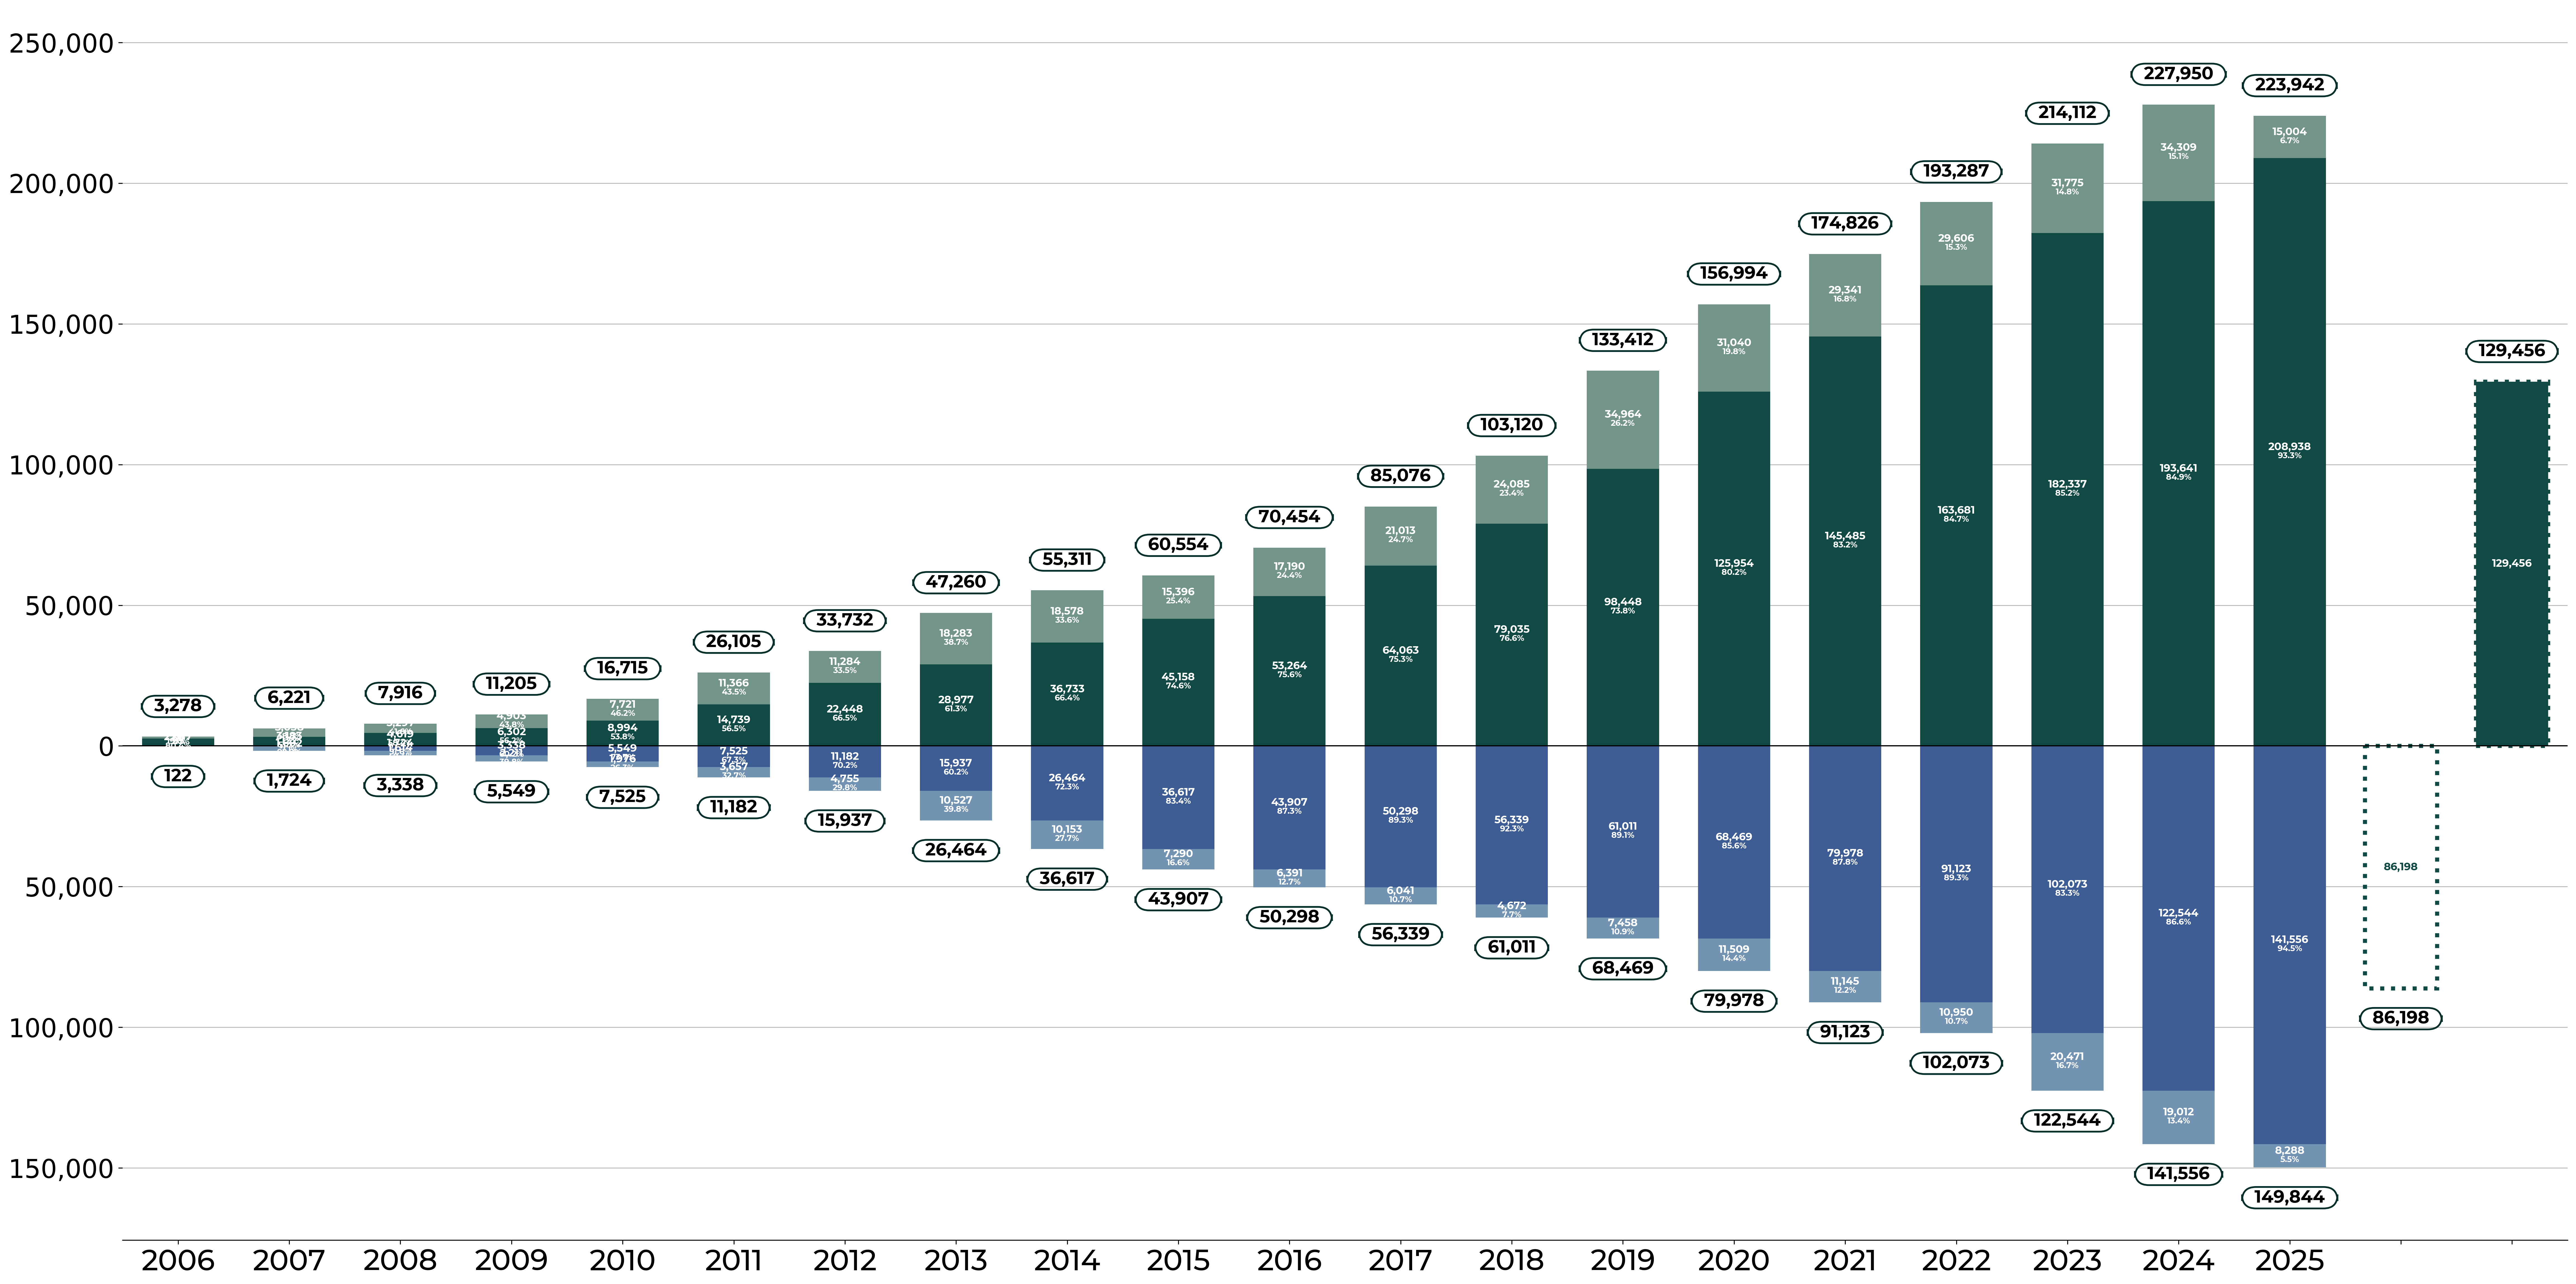

In [12]:
    barras_verticales(dataframes_filtrados[list(dataframes_filtrados.keys())[0]], 
       nombre=f"dataframe_{list(dataframes_filtrados.keys())[0]}", 
       bar_height=0.65, 
       font='Montserrat',
       fontsize_barra=9,
       fontsize_barra_porcentaje=7,
       fontsize_valor_total=15,
       ordenar_por=False,
       orden='ascendente',
       valor_barra=True, 
       valor_total=True,
       porcentaje_barra=True,
       porcentaje_total=False,
       area_min=0,
       porcentaje_abajo=True,
       leyenda=False,
       orientacion_etiqueta_x='horizontal',
       posicion_leyenda='abajo',
       porcentaje_divergente=True,
       ejeY_negativo_a_positivo=True,
       paleta_colores=["#114a44", "#739489", "#3d5c93", "#7393b3", "#6B5B95",],
       agregar_datos=[(pd.Timestamp(2026, 1, 1), " ", (0,0,0,0,-86198), [None, None, None, None, "86,198"], {'colores_fondo': [None, None, None, None, 'none'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, '#114a44']}),
                      (pd.Timestamp(2027, 1, 1), " ", (0,0,0,0,129456), [None, None, None, None, "129,456"], {'colores_fondo': [None, None, None, None, '#114a44'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, 'white']})
                      ],
       capsulas_cero=False,
       ncol_leyenda=2,
       aumenta_sep_eje_x=-0.33,
       division_ejeY=50000,
       )

Scour processed file "output/dataframe_2.svg" in 104 ms: 60577/99556 bytes new/orig -> 60.8%

dataframe_2_scour.svg:
Done in 148 ms!
59.157 KiB - 21% = 46.755 KiB


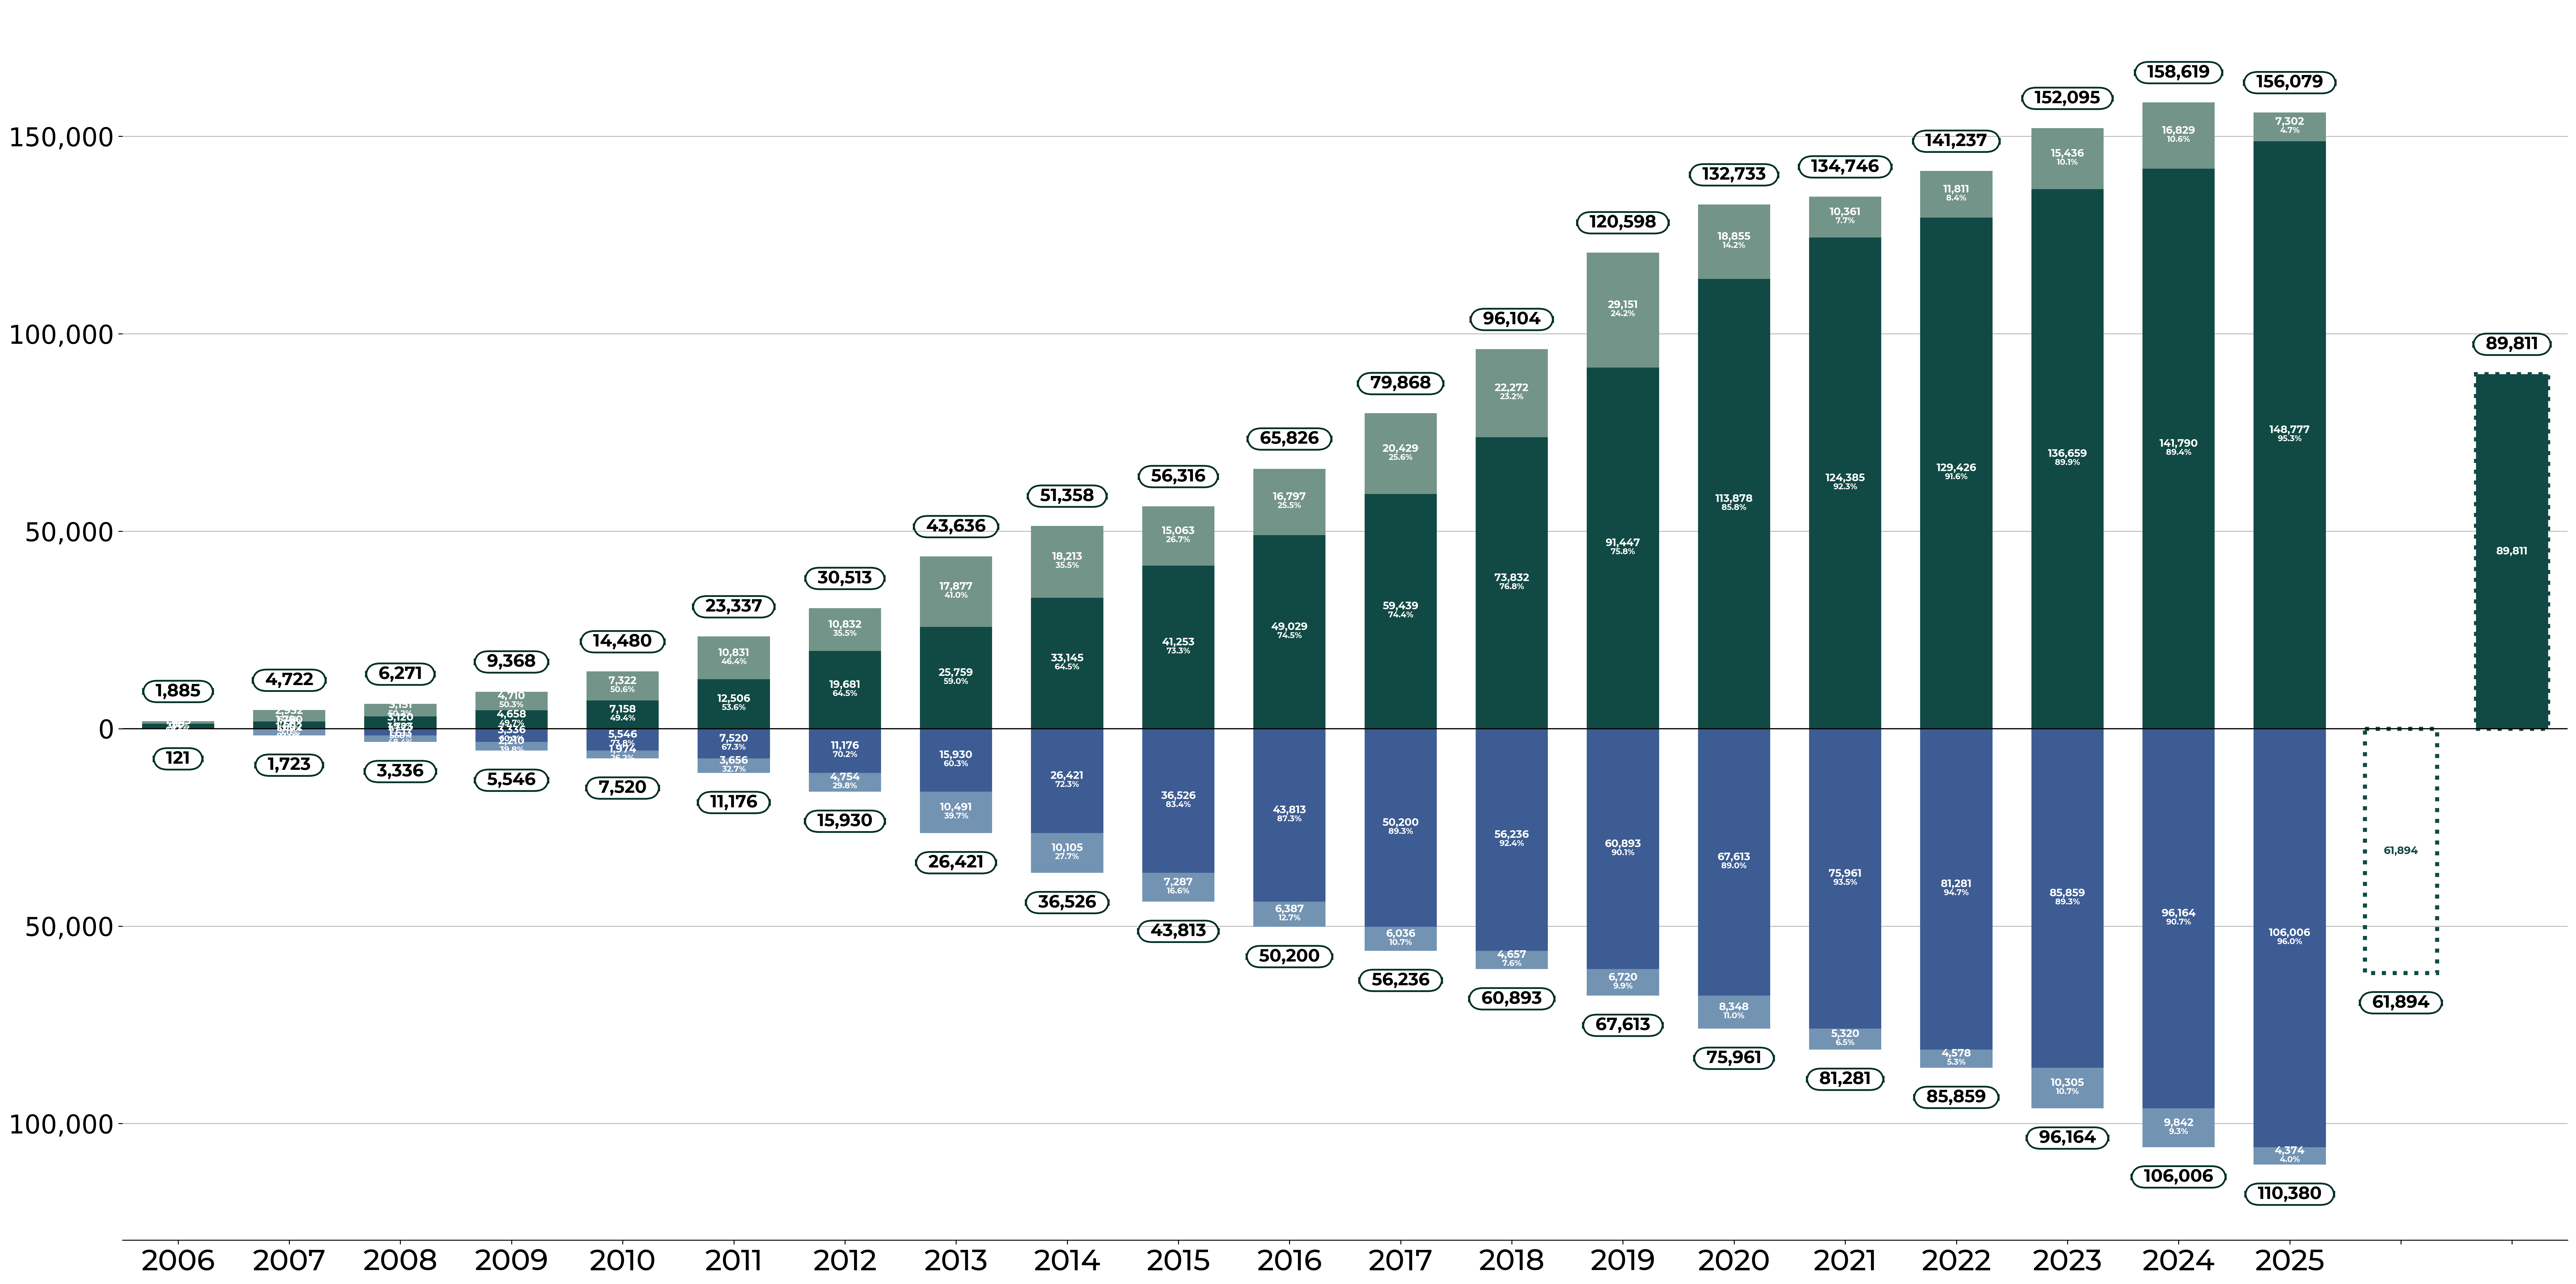

In [14]:
    barras_verticales(dataframes_filtrados[list(dataframes_filtrados.keys())[1]], 
       nombre=f"dataframe_{list(dataframes_filtrados.keys())[1]}", 
       bar_height=0.65, 
       font='Montserrat',
       fontsize_barra=9,
        fontsize_barra_porcentaje=7,
       fontsize_valor_total=15,
       ordenar_por=False,
       orden='ascendente',
       valor_barra=True, 
       valor_total=True,
       porcentaje_barra=True,
       porcentaje_total=False,
       area_min=0,
       porcentaje_abajo=True,
       leyenda=False,
       orientacion_etiqueta_x='horizontal',
       posicion_leyenda='abajo',
       porcentaje_divergente=True,
       ejeY_negativo_a_positivo=True,
       paleta_colores=["#114a44", "#739489", "#3d5c93", "#7393b3", "#6B5B95",],
       agregar_datos=[(pd.Timestamp(2026, 1, 1), " ", (0,0,0,0,-61894), [None, None, None, None, "61,894"], {'colores_fondo': [None, None, None, None, 'none'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, '#114a44']}),
                      (pd.Timestamp(2027, 1, 1), " ", (0,0,0,0,89811), [None, None, None, None, "89,811"], {'colores_fondo': [None, None, None, None, '#114a44'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, 'white']})
                      ],
       capsulas_cero=False,
       ncol_leyenda=2,
       aumenta_sep_eje_x=-0.29,
       division_ejeY=50000,
       )

Scour processed file "output/dataframe_3.svg" in 56 ms: 34585/57160 bytes new/orig -> 60.5%

dataframe_3_scour.svg:
Done in 97 ms!
33.774 KiB - 21.3% = 26.564 KiB


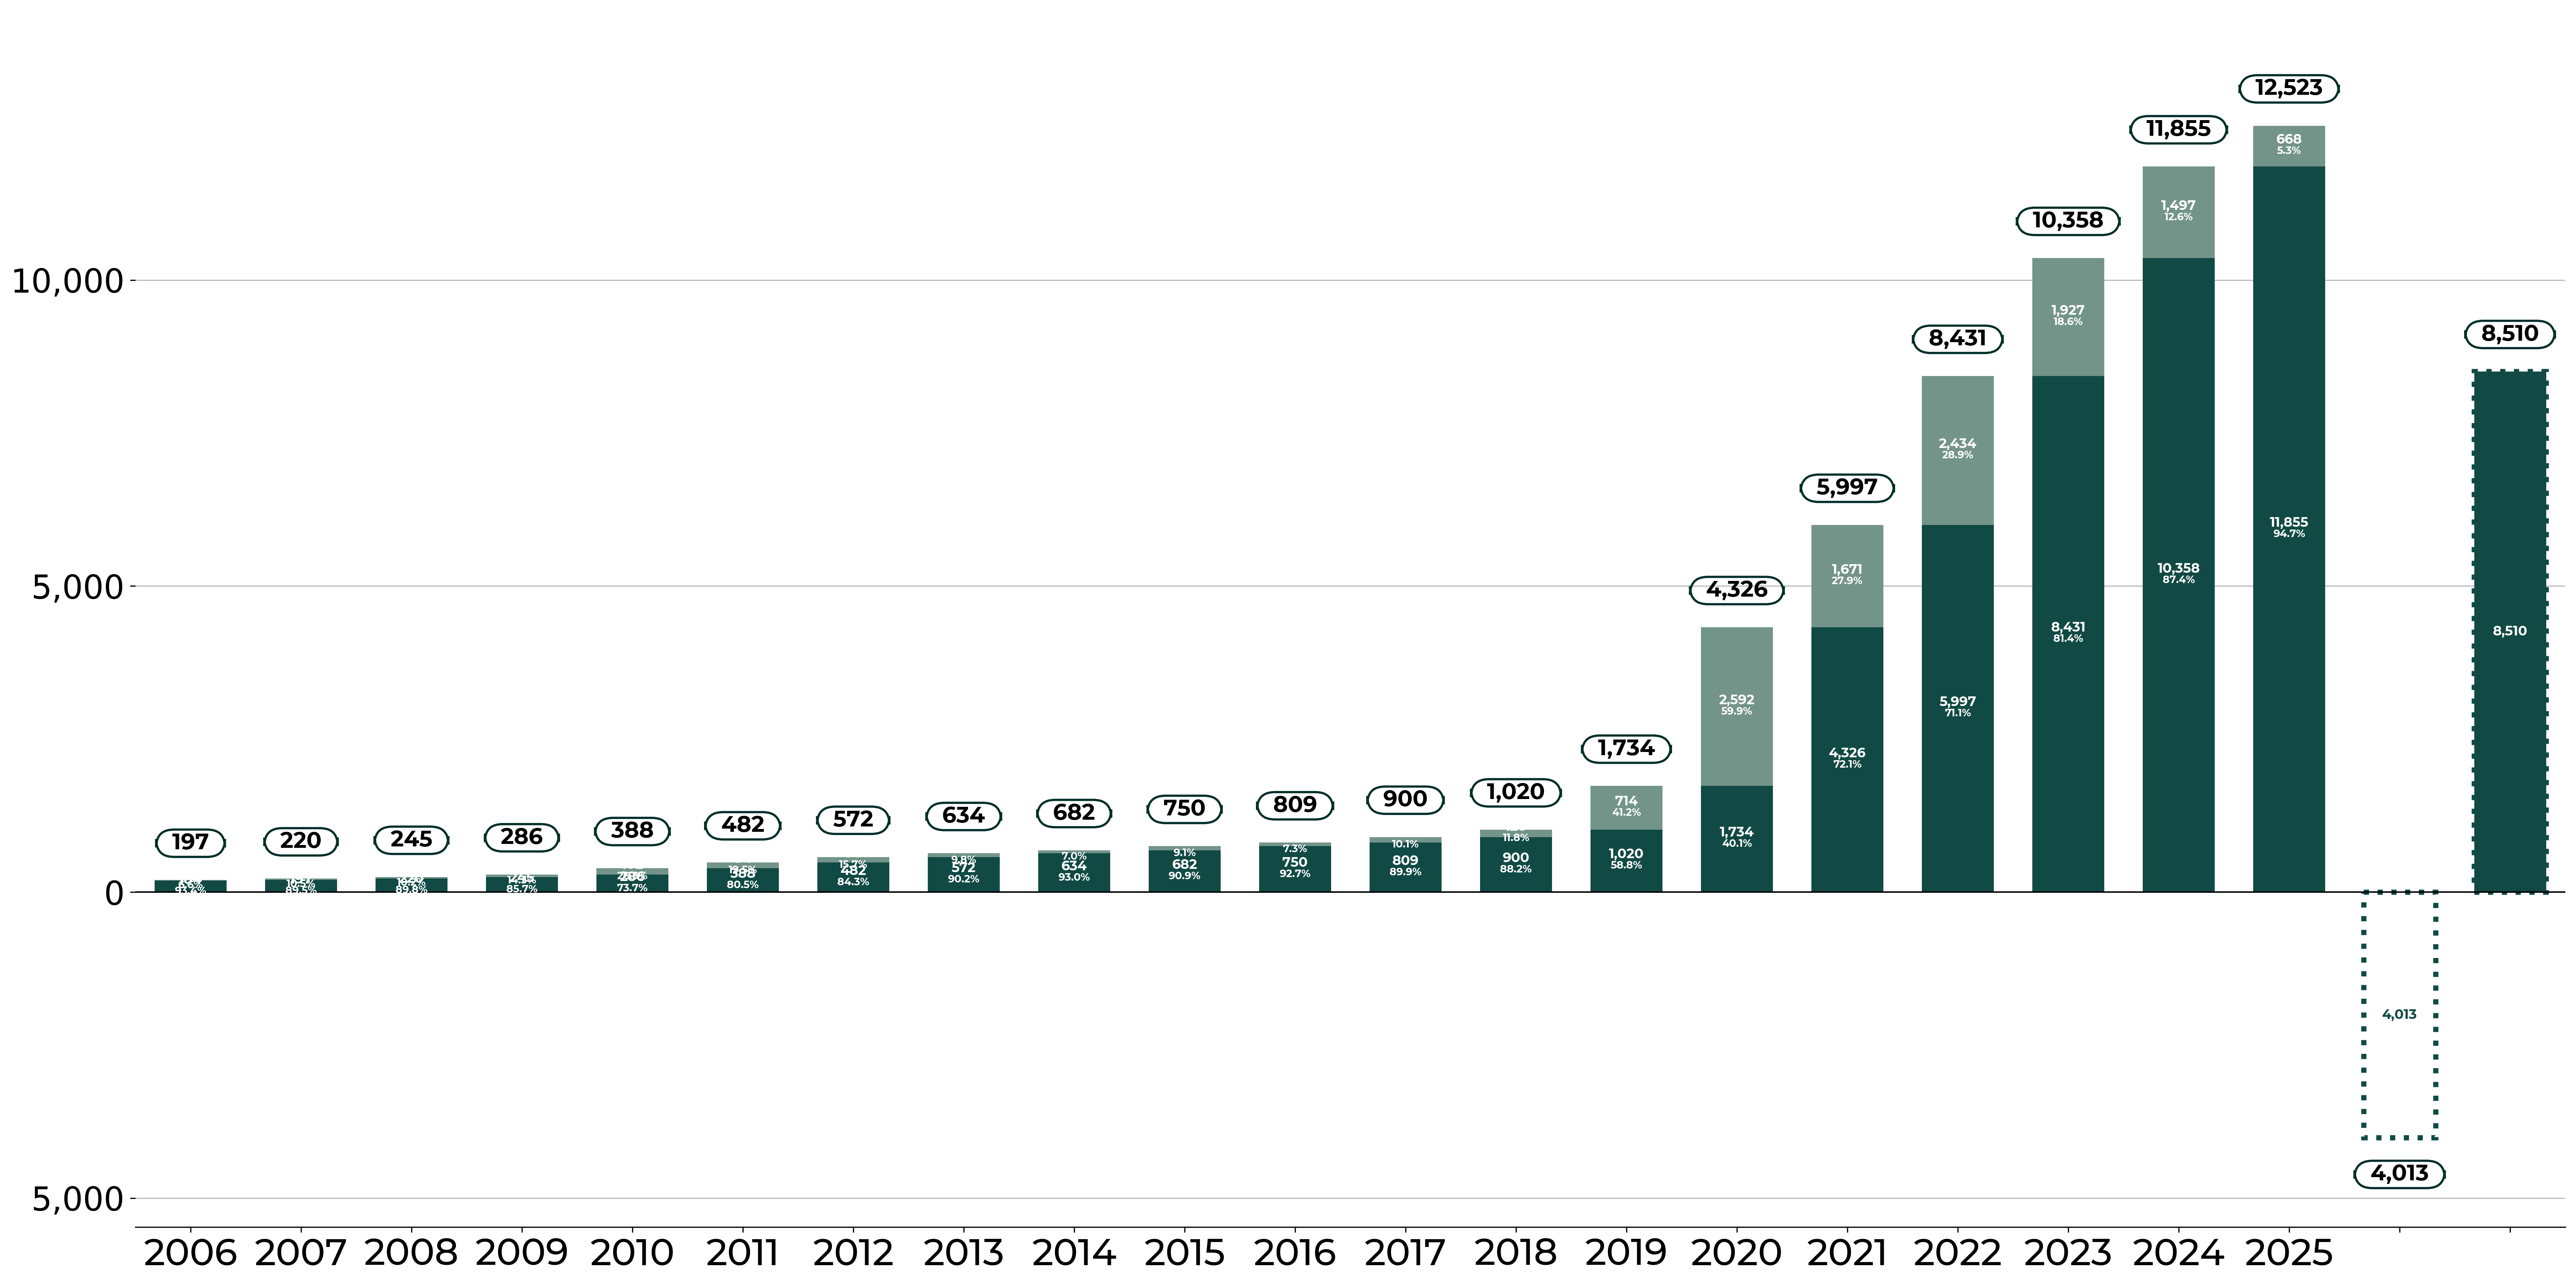

In [15]:
    barras_verticales(dataframes_filtrados[list(dataframes_filtrados.keys())[2]], 
       nombre=f"dataframe_{list(dataframes_filtrados.keys())[2]}", 
       bar_height=0.65, 
       font='Montserrat',
       fontsize_barra=9,
       fontsize_barra_porcentaje=7,
       fontsize_valor_total=15,
       ordenar_por=False,
       orden='ascendente',
       valor_barra=True, 
       valor_total=True,
       porcentaje_barra=True,
       porcentaje_total=False,
       area_min=0,
       porcentaje_abajo=True,
       leyenda=False,
       orientacion_etiqueta_x='horizontal',
       posicion_leyenda='abajo',
       porcentaje_divergente=True,
       ejeY_negativo_a_positivo=True,
       paleta_colores=["#114a44", "#739489", "#3d5c93", "#7393b3", "#6B5B95",],
       agregar_datos=[(pd.Timestamp(2026, 1, 1), " ", (0,0,0,0,-4013), [None, None, None, None, "4,013"], {'colores_fondo': [None, None, None, None, 'none'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, '#114a44']}),
                      (pd.Timestamp(2027, 1, 1), " ", (0,0,0,0,8510), [None, None, None, None, "8,510"], {'colores_fondo': [None, None, None, None, '#114a44'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, 'white']})
                      ],
       capsulas_cero=False,
       ncol_leyenda=2,
       aumenta_sep_eje_x=-0.62,
       division_ejeY=False,
       )

Scour processed file "output/dataframe_4.svg" in 142 ms: 50147/83446 bytes new/orig -> 60.1%

dataframe_4_scour.svg:
Done in 138 ms!
48.972 KiB - 20.6% = 38.877 KiB


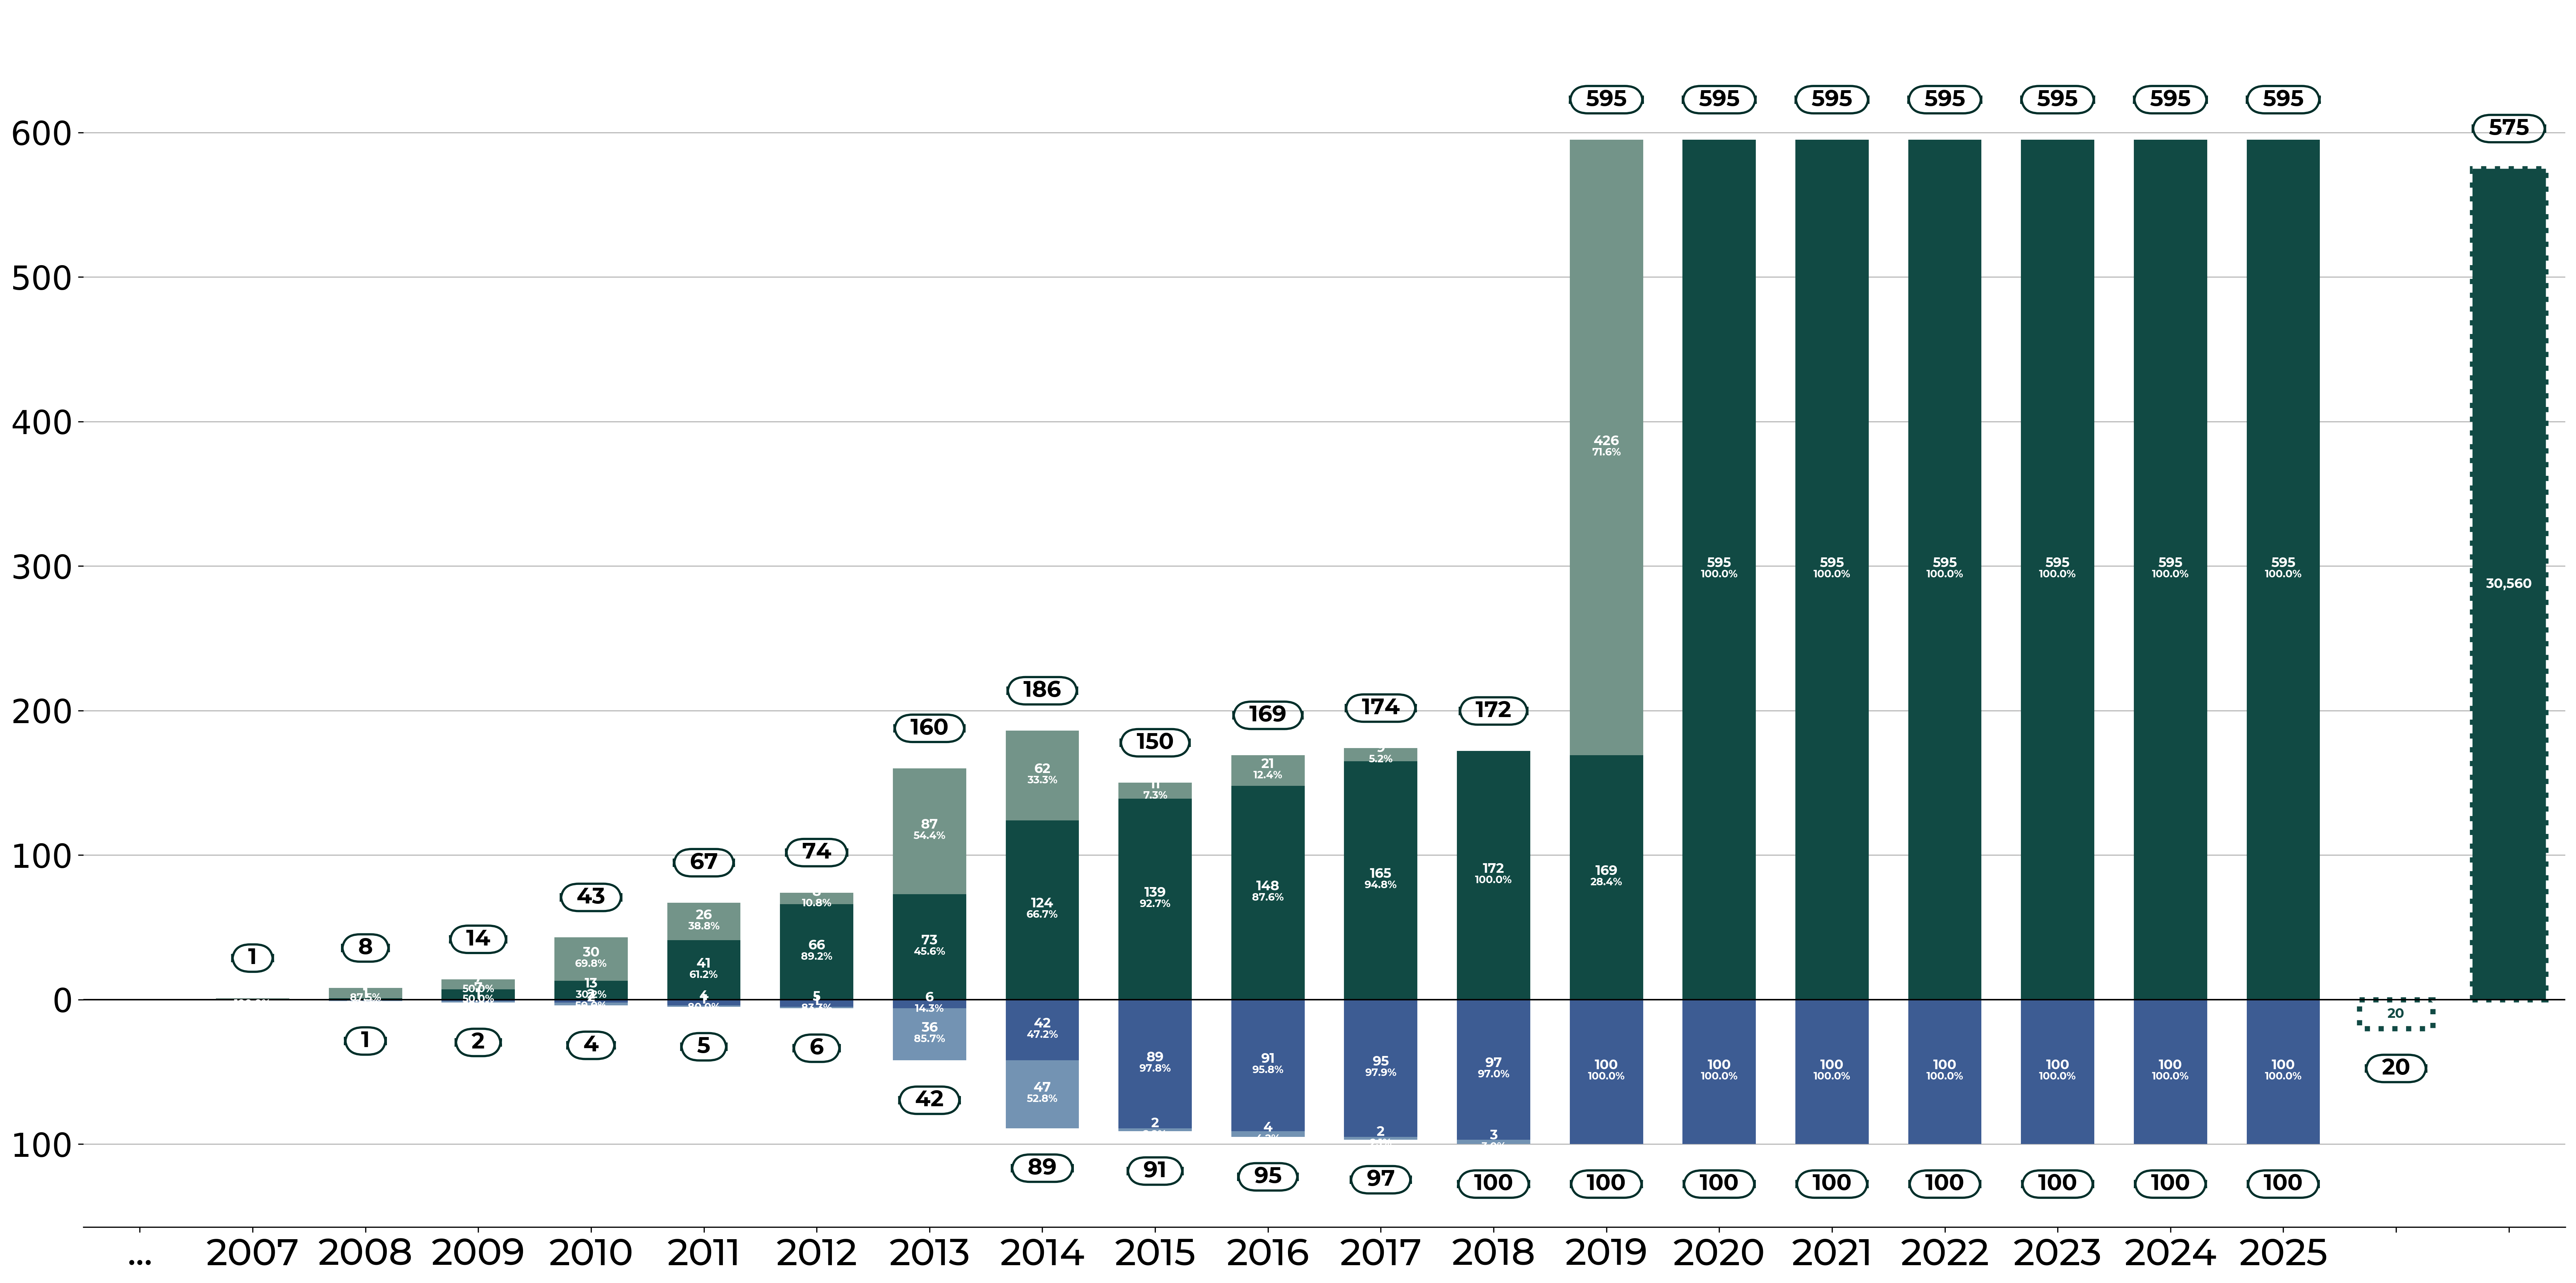

In [19]:
    barras_verticales(dataframes_filtrados[list(dataframes_filtrados.keys())[3]], 
       nombre=f"dataframe_{list(dataframes_filtrados.keys())[3]}", 
       bar_height=0.65, 
       font='Montserrat',
       fontsize_barra=9,
       fontsize_barra_porcentaje=7,
       fontsize_valor_total=15,
       ordenar_por=False,
       orden='ascendente',
       valor_barra=True, 
       valor_total=True,
       porcentaje_barra=True,
       porcentaje_total=False,
       area_min=0,
       porcentaje_abajo=True,
       leyenda=False,
       orientacion_etiqueta_x='horizontal',
       posicion_leyenda='abajo',
       porcentaje_divergente=True,
       ejeY_negativo_a_positivo=True,
       paleta_colores=["#114a44", "#739489", "#3d5c93", "#7393b3", "#6B5B95",],
       agregar_datos=[(pd.Timestamp(2026, 1, 1), " ", (0,0,0,0,-20), [None, None, None, None, "20"], {'colores_fondo': [None, None, None, None, 'none'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, '#114a44']}),
                      (pd.Timestamp(2027, 1, 1), " ", (0,0,0,0,575), [None, None, None, None, "30,560"], {'colores_fondo': [None, None, None, None, '#114a44'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, 'white']})
                      ],
       capsulas_cero=False,
       ncol_leyenda=2,
       aumenta_sep_eje_x=-0.77,
       division_ejeY=False,
       )

Scour processed file "output/dataframe_5.svg" in 163 ms: 56260/93368 bytes new/orig -> 60.3%

dataframe_5_scour.svg:
Done in 176 ms!
54.941 KiB - 21% = 43.426 KiB


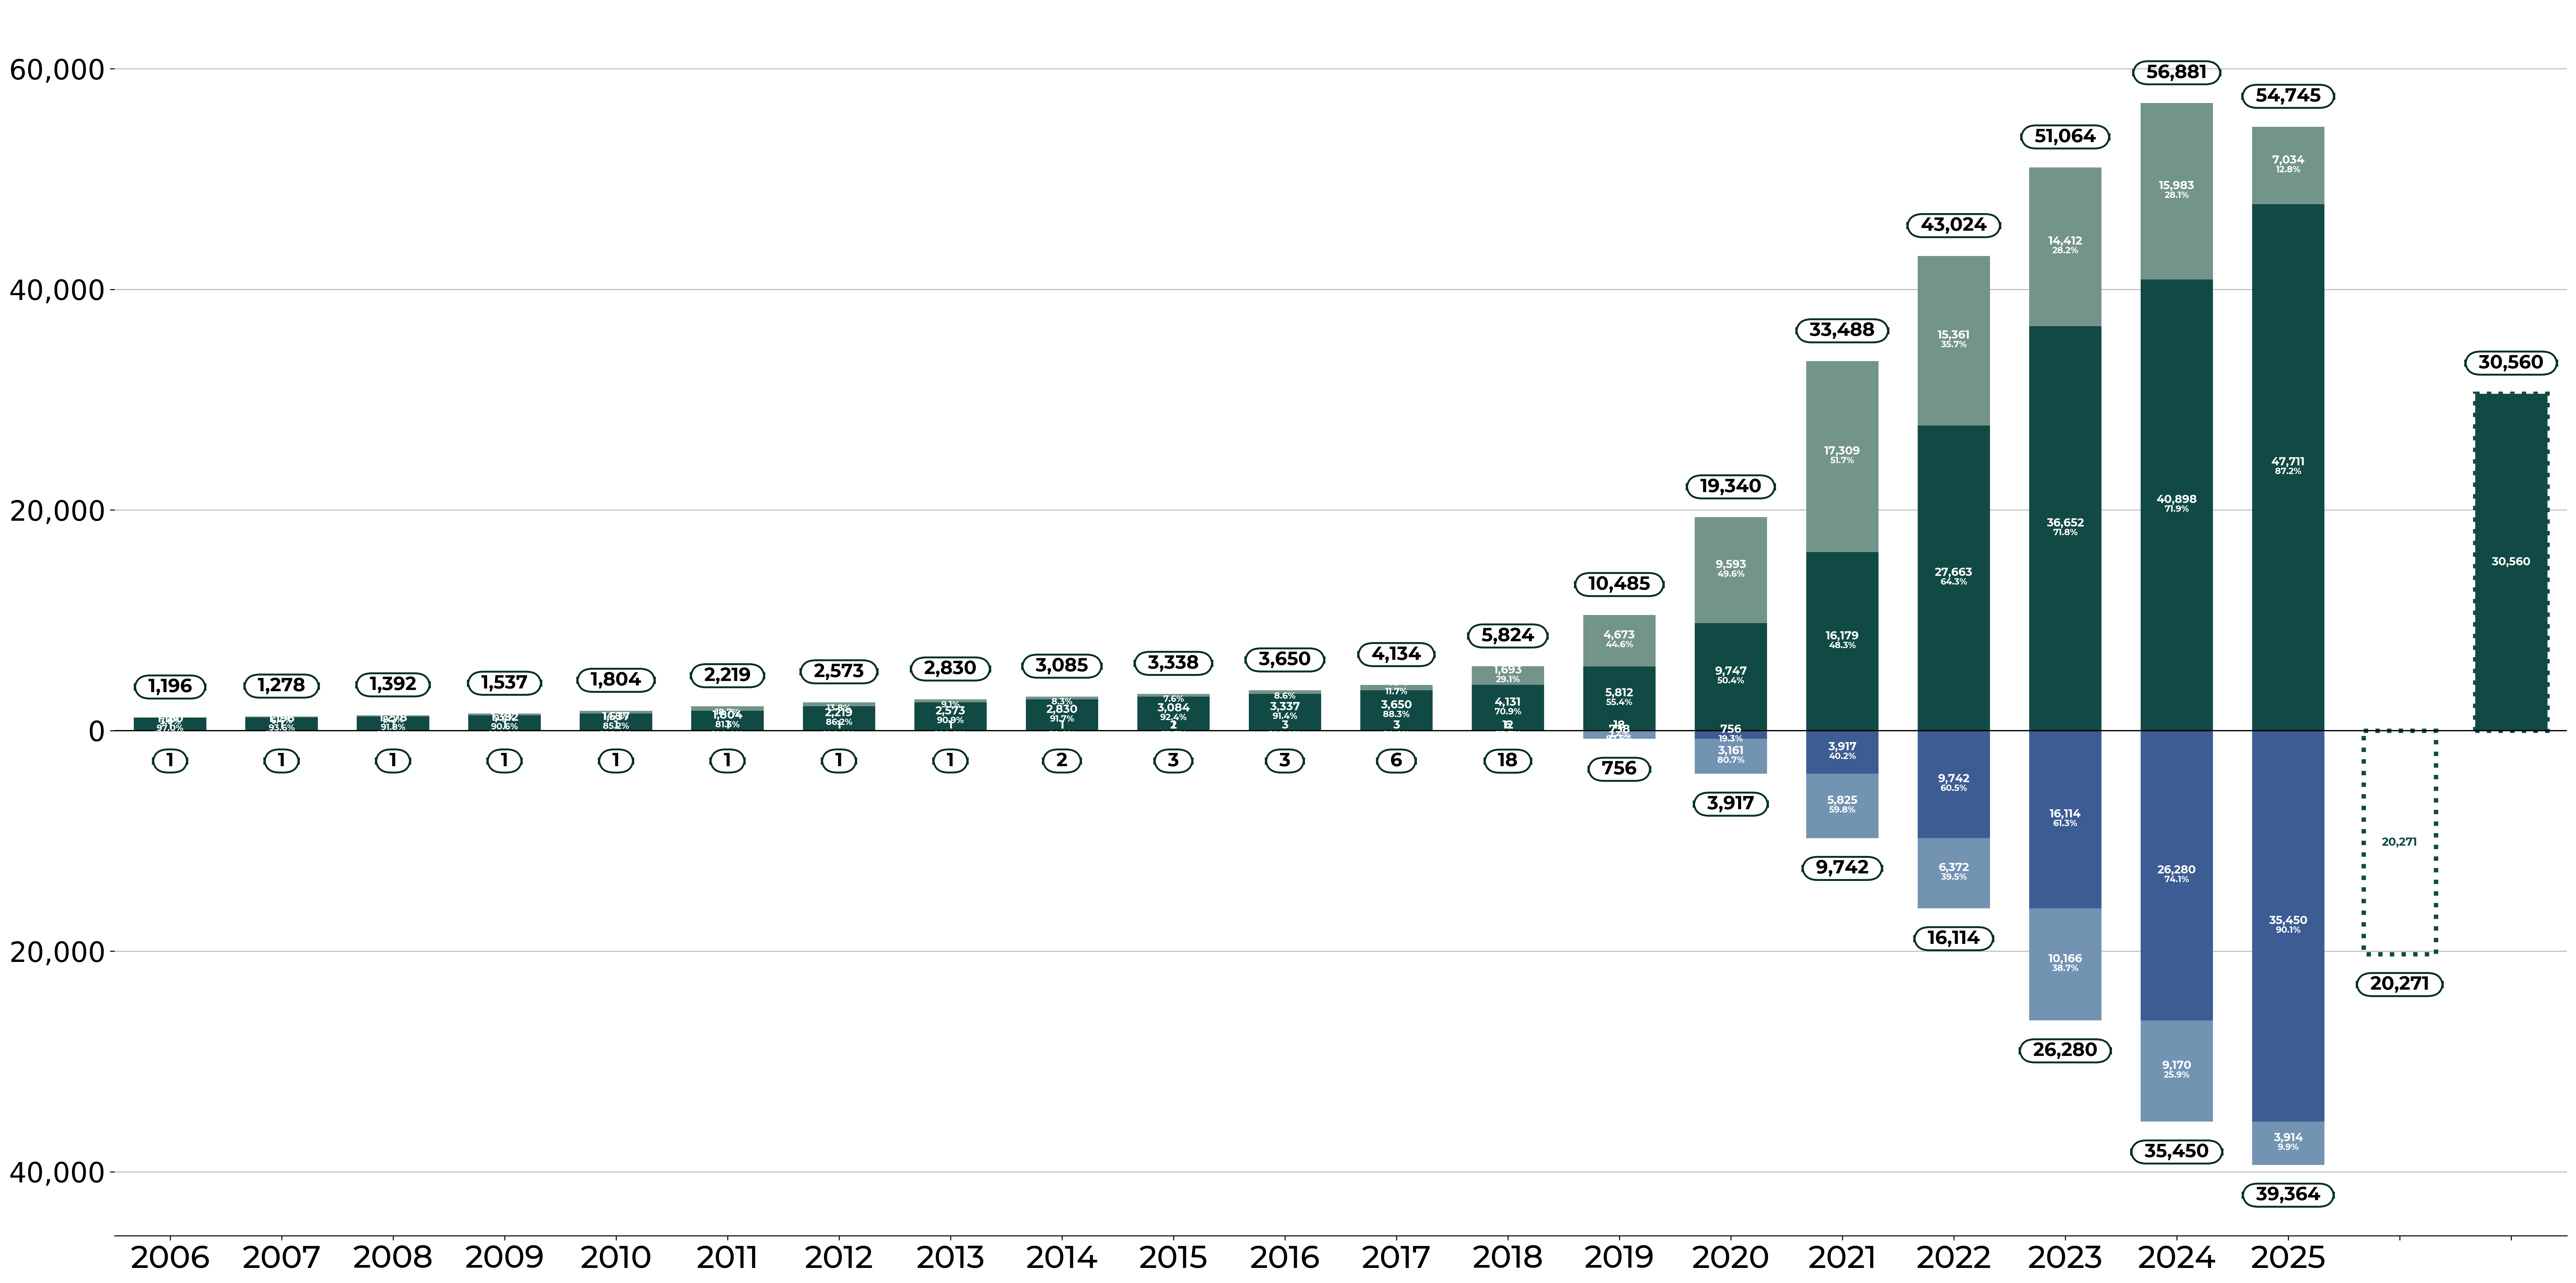

In [18]:
    barras_verticales(dataframes_filtrados[list(dataframes_filtrados.keys())[4]], 
       nombre=f"dataframe_{list(dataframes_filtrados.keys())[4]}", 
       bar_height=0.65, 
       font='Montserrat',
       fontsize_barra=9,
       fontsize_barra_porcentaje=7,
       fontsize_valor_total=15,
       ordenar_por=False,
       orden='ascendente',
       valor_barra=True, 
       valor_total=True,
       porcentaje_barra=True,
       porcentaje_total=False,
       area_min=0,
       porcentaje_abajo=True,
       leyenda=False,
       orientacion_etiqueta_x='horizontal',
       posicion_leyenda='abajo',
       porcentaje_divergente=True,
       ejeY_negativo_a_positivo=True,
       paleta_colores=["#114a44", "#739489", "#3d5c93", "#7393b3", "#6B5B95",],
       agregar_datos=[(pd.Timestamp(2026, 1, 1), " ", (0,0,0,0,-20271), [None, None, None, None, "20,271"], {'colores_fondo': [None, None, None, None, 'none'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, '#114a44']}),
                      (pd.Timestamp(2027, 1, 1), " ", (0,0,0,0,30560), [None, None, None, None, "30,560"], {'colores_fondo': [None, None, None, None, '#114a44'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, 'white']}) 
                      ],
       capsulas_cero=False,
       ncol_leyenda=2,
       aumenta_sep_eje_x=-0.3,
       division_ejeY=False,
       )

Scour processed file "output/dataframe_6.svg" in 178 ms: 60457/99575 bytes new/orig -> 60.7%

dataframe_6_scour.svg:
Done in 167 ms!
59.04 KiB - 21.2% = 46.533 KiB


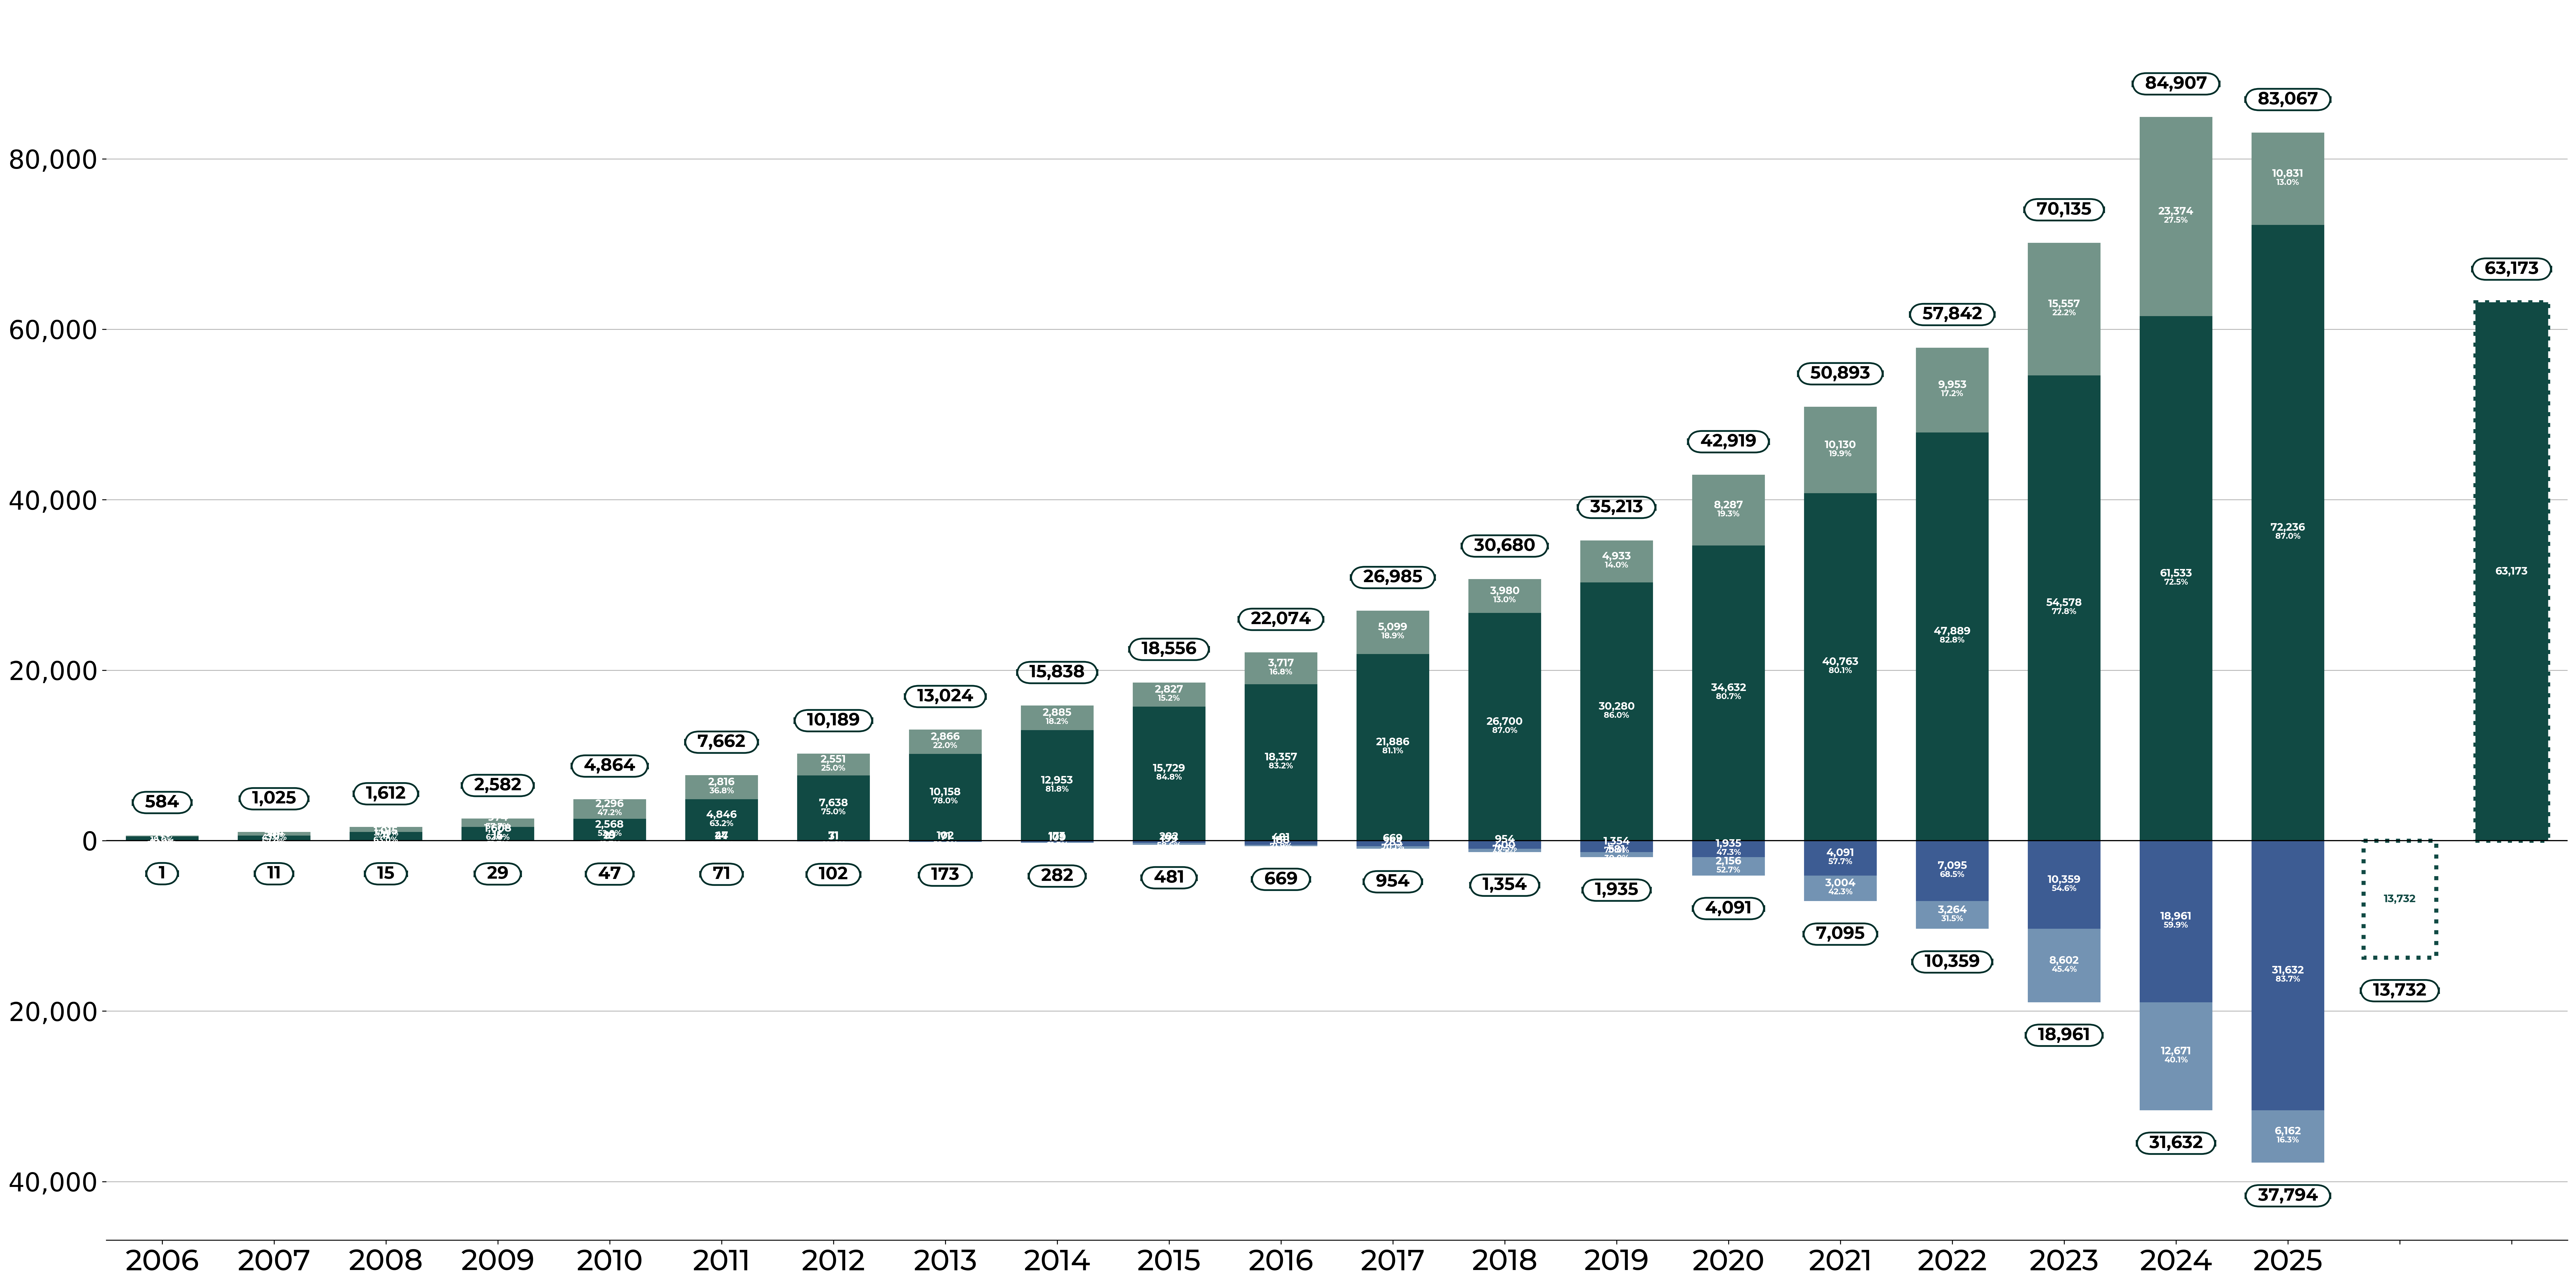

In [20]:
  barras_verticales(dataframes_filtrados[list(dataframes_filtrados.keys())[5]], 
       nombre=f"dataframe_{list(dataframes_filtrados.keys())[5]}", 
       bar_height=0.65, 
       font='Montserrat',
       fontsize_barra=9,
       fontsize_barra_porcentaje=7,
       fontsize_valor_total=15,
       ordenar_por=False,
       orden='ascendente',
       valor_barra=True, 
       valor_total=True,
       porcentaje_barra=True,
       porcentaje_total=False,
       area_min=0,
       porcentaje_abajo=True,
       leyenda=False,
       orientacion_etiqueta_x='horizontal',
       posicion_leyenda='abajo',
       porcentaje_divergente=True,
       ejeY_negativo_a_positivo=True,
       paleta_colores=["#114a44", "#739489", "#3d5c93", "#7393b3", "#6B5B95",],
       agregar_datos=[(pd.Timestamp(2026, 1, 1), " ", (0,0,0,0,-13732), [None, None, None, None, "13,732"], {'colores_fondo': [None, None, None, None, 'none'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, '#114a44']}),
                      (pd.Timestamp(2027, 1, 1), " ", (0,0,0,0,63173), [None, None, None, None, "63,173"], {'colores_fondo': [None, None, None, None, '#114a44'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, 'white']})
                      ],
       capsulas_cero=False,
       ncol_leyenda=2,
       aumenta_sep_eje_x=-0.52,
       #division_ejeY=50000,
       )

Scour processed file "output/dataframe_7.svg" in 184 ms: 60588/99605 bytes new/orig -> 60.8%

dataframe_7_scour.svg:
Done in 167 ms!
59.168 KiB - 21% = 46.769 KiB


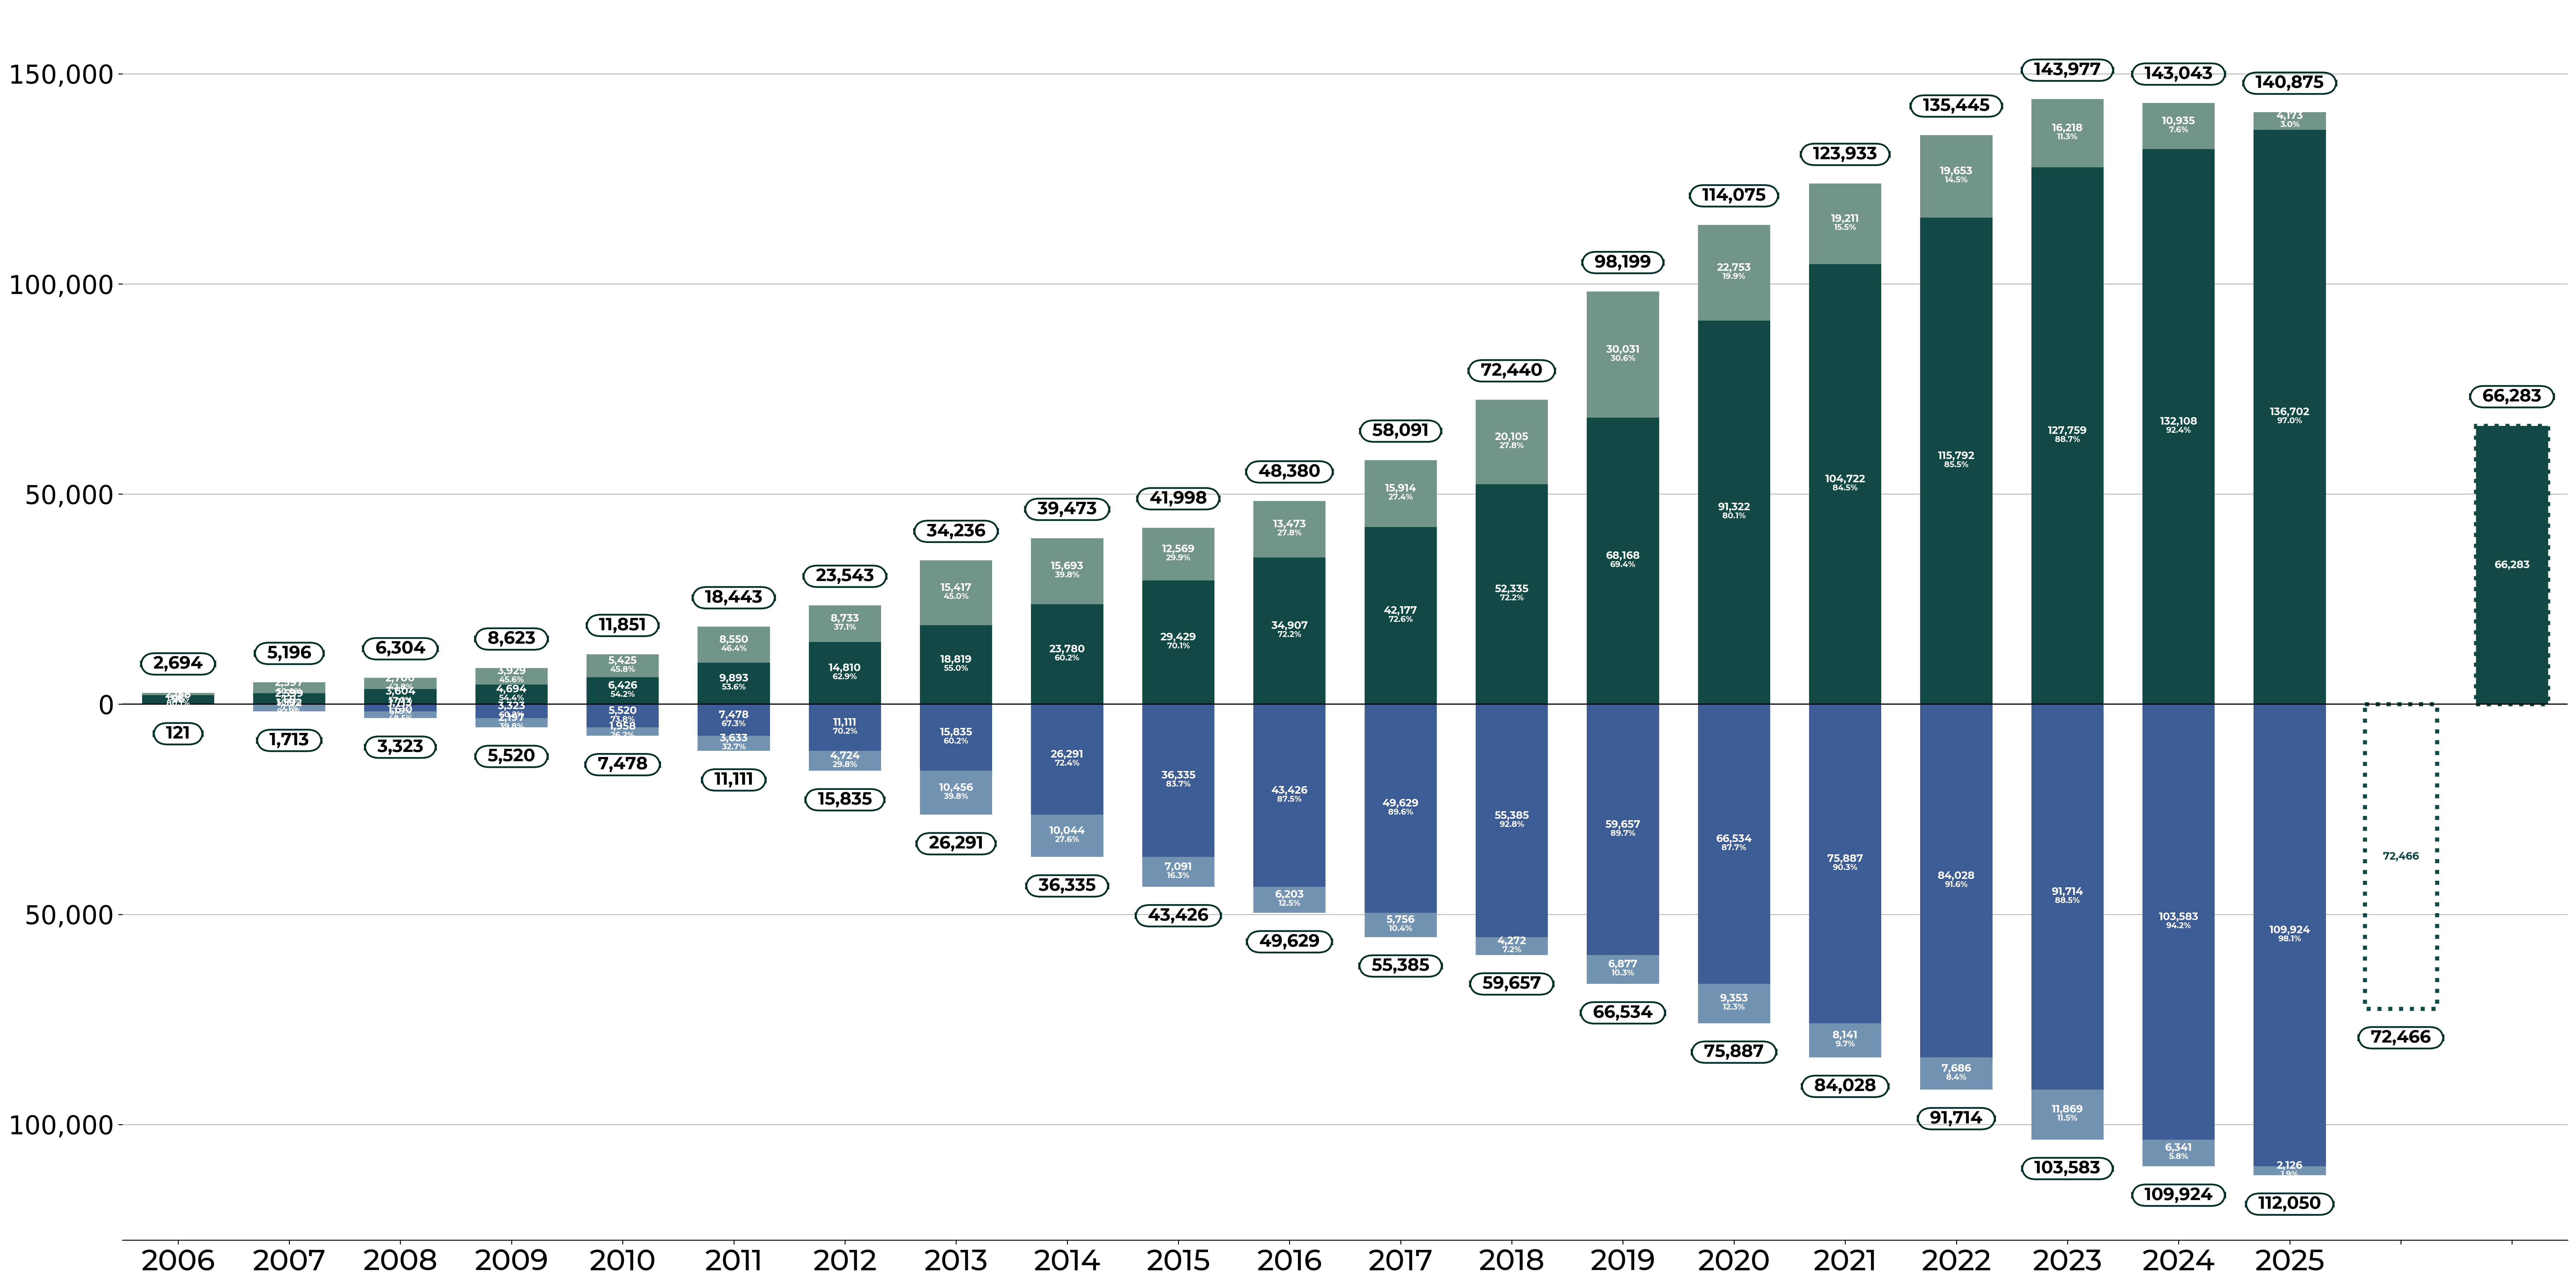

In [21]:
  barras_verticales(dataframes_filtrados[list(dataframes_filtrados.keys())[6]], 
       nombre=f"dataframe_{list(dataframes_filtrados.keys())[6]}", 
       bar_height=0.65, 
       font='Montserrat',
       fontsize_barra=9,
       fontsize_barra_porcentaje=7,
       fontsize_valor_total=15,
       ordenar_por=False,
       orden='ascendente',
       valor_barra=True, 
       valor_total=True,
       porcentaje_barra=True,
       porcentaje_total=False,
       area_min=0,
       porcentaje_abajo=True,
       leyenda=False,
       orientacion_etiqueta_x='horizontal',
       posicion_leyenda='abajo',
       porcentaje_divergente=True,
       ejeY_negativo_a_positivo=True,
       paleta_colores=["#114a44", "#739489", "#3d5c93", "#7393b3", "#6B5B95",],
       agregar_datos=[(pd.Timestamp(2026, 1, 1), " ", (0,0,0,0,-72466), [None, None, None, None, "72,466"], {'colores_fondo': [None, None, None, None, 'none'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, '#114a44']}),
                      (pd.Timestamp(2027, 1, 1), " ", (0,0,0,0,66283), [None, None, None, None, "66,283"], {'colores_fondo': [None, None, None, None, '#114a44'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, 'white']})
                      ],
       capsulas_cero=False,
       ncol_leyenda=2,
       aumenta_sep_eje_x=-0.23,
       division_ejeY=50000,
       )